# Methodology: Time-to-Event Prediction

### Goal
For each open deal, predict **when** it is expected to close, at week, month, and quarter granularity. 

Prediction quality is measured by the deviation (`Delta`) from actual close dates on a held-out evaluation set of closed deals.

### Approach

**Step 1 – Survival Model (Ranking)**

We train a survival model that estimates a **survival function S(t)** for each deal: the probability that a deal is still open at time *t*. Models like Random Survival Forest or XGBoost Survival learn which deals close quickly vs. slowly, measured by the **Concordance Index (C-Index)**, which indicates how well the relative ranking of deals is predicted (0.5 = random, 1.0 = perfect).

**Step 2 – Median Survival Time as a Concrete Time Estimate**

From the survival function we derive the **Median Survival Time**: the point where S(t) = 0.5 (i.e., the time by which statistically half of all comparable deals have closed). This is the best single point estimate for the expected time-to-close.

```
Predicted Close Date = Registered Date + Median Survival Time (in days)
```

**Step 3 – Deviation Analysis (Delta)**

For closed deals we compare the predicted vs. actual close date and compute the delta at four granularities:

| Column | Content |
|---|---|
| `predicted_close_date` / `actual_close_date` / `delta_days` | Absolute date prediction and deviation in days |
| `predicted_week` / `actual_week` / `delta_weeks` | Calendar week comparison |
| `predicted_month` / `actual_month` / `delta_months` | Month comparison (YYYY-MM) |
| `predicted_quarter` / `actual_quarter` / `delta_quarters` | Quarter comparison |

### Why This Approach?

- **Statistically sound:** Survival models correctly handle censored observations --> still-open deals (classical regression would ignore or distort these cases).
- **Flexible:** A single model simultaneously delivers the ranking (C-Index), the absolute time estimate (Median), and predictions at any granularity.
- **Measurable:** The delta allows direct, stakeholder-friendly evaluation: *"Our quarterly forecast is off by X quarters on the median."*
- **Production-ready:** The model is designed to score open deals using their **current state**, not just creation-time features. This means predictions update as deals evolve: a deal that has progressed to a late stage or had its probability raised will receive a faster predicted closure than it did at registration.

### Feature Philosophy: Creation-time vs. Current State

A key decision in this notebook is which features we use at prediction time.

We distinguish three groups:

| Group | Examples | Production use |
|---|---|---|
| **Creation-time** | `prob_init`, `stage_merged`, `log_amount` | Known at deal registration, never change |
| **Current state** | `prob_last_open`, `stage_last_open_merged`, `resp_change`, `days_since_last_update`, `amount_changes` | Updated as deals evolve — use current value at prediction time |
| **CRM hygiene flagged** | `close_date_shift`, `total_days_pushed` | Available but reliability depends on rep CRM discipline |

**Important:** Current state features are **not** data leakage in a production context. For open deals, all of these values are available at prediction time from the latest changelog entry. The leakage concern only applies if you predict at deal creation and never update, which is not the intended use case.

### Why XGBoost AFT?

After comparing four survival models (GBSA, RSF, XGBoost Cox, XGBoost AFT), AFT is selected as the production model for two reasons:

1. **Absolute time predictions** — AFT directly predicts days-to-close, which Cox cannot. Cox only produces a relative ranking.
2. **C-Index parity** — AFT and Cox achieve essentially the same C-Index on the validation set, so there is no ranking accuracy cost to choosing AFT.

The AFT model uses a `normal` loss distribution, justified by the approximately log-normal distribution of deal durations (validated via QQ-plot, skewness = -0.086).

### C-Index and its limitations for AFT

The C-Index measures whether the model correctly ranks deals by closure speed, it does not measure absolute accuracy. For AFT the more important metrics are the **Delta analysis** in Step 3: % exact quarter, % within ±1 quarter. The C-Index is used only for model selection, not as the primary success criterion.

In [1]:
#!pip install pandas matplotlib numpy scikit-learn scikit-survival pyarrow xgboost pycox torch

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import datetime
import sklearn
import sksurv
import pyarrow
import xgboost as xgb
import pycox
import torch
import scipy.stats as stats
from sksurv.util import Surv
from sklearn.preprocessing import OrdinalEncoder

from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored
from sksurv.ensemble import RandomSurvivalForest

In [ ]:
df = pd.read_parquet("../data/df_cph_ready.parquet")
df.isna().sum()

chance_id                       0
business_unit                   0
responsible                     0
registered_dt                   0
registered_by_id                0
updated_dt                      0
updated_by_id                   0
status                          0
stage_en                        0
probability                     0
amount                          0
saledate                     4240
org_id                          0
org_country                     0
org_category_en                 0
intercompany_flag               0
chance_type_en                  0
has_products_and_services       0
days_until_saledate             0
target_won                   5540
resp_change                     0
days_since_last_update          0
product_change_flag             0
close_date_shift                0
total_days_pushed               0
saledate_delta                  0
amount_changes                  0
home_country                    0
deal_age                        0
zombie_deal   

In [4]:
df.head()

,chance_id,business_unit,responsible,registered_dt,registered_by_id,updated_dt,updated_by_id,status,stage_en,probability,...,stage_last_open,prob_is_default,stage_merged,stage_last_open_merged,log_amount,log_rep_amount,log_deal_share_rep,rep_no_prior_closes,amount_change_bucket,saledate_ever_updated
0,821c2ad09552bc2b,ef9b14cf5a29c54a,cbf8dd8b4b47540c,2025-08-13 10:23:22,cbf8dd8b4b47540c,2026-01-05 16:57:34,cbf8dd8b4b47540c,Open,Information Stage,0.109890,...,Information Stage,0,Mid,Mid,14.084691,4.477337,4.862466e-02,0,0,1
1,f69fa4037b56be65,ef9b14cf5a29c54a,cbf8dd8b4b47540c,2025-04-30 13:39:24,cbf8dd8b4b47540c,2026-01-05 16:57:04,cbf8dd8b4b47540c,Open,Information Stage,0.274725,...,Information Stage,0,Mid,Mid,13.740086,4.477337,3.469305e-02,0,2–3,1
2,209f07e3db7c9ea3,ef9b14cf5a29c54a,cbf8dd8b4b47540c,2024-11-07 12:29:15,cbf8dd8b4b47540c,2026-01-05 16:56:04,cbf8dd8b4b47540c,Open,Order received - Sales,1.000000,...,Order received - Sales,0,Mid,Late,14.550152,4.477337,7.636889e-02,0,4+,1
3,389db7faa4d5957d,ac2a5ee6878db2c2,4b4e7aa9d1b4264b,2024-07-29 12:23:46,4b4e7aa9d1b4264b,2026-01-05 16:14:34,4b4e7aa9d1b4264b,Lost,Information Stage,0.000000,...,Information Stage,1,Mid,Mid,0.775125,5.214936,1.581659e-08,0,0,1
4,b4e48d600e79173e,ac2a5ee6878db2c2,4b4e7aa9d1b4264b,2025-02-26 10:38:45,4b4e7aa9d1b4264b,2026-01-05 16:14:03,4b4e7aa9d1b4264b,Open,Lead,0.000000,...,Lead,1,Mid,Early,0.775125,5.214936,1.581659e-08,0,0,1


In [5]:
df.tail()

,chance_id,business_unit,responsible,registered_dt,registered_by_id,updated_dt,updated_by_id,status,stage_en,probability,...,stage_last_open,prob_is_default,stage_merged,stage_last_open_merged,log_amount,log_rep_amount,log_deal_share_rep,rep_no_prior_closes,amount_change_bucket,saledate_ever_updated
30173,ed883a79eea8b6f1,1cdd086394501fee,831ae51da38a0629,2019-01-10 13:42:44,831ae51da38a0629,2019-01-10 14:25:32,831ae51da38a0629,Open,Proposal stage,0.329670,...,Proposal stage,0,Mid,Mid,5.277458,0.693147,0.693147,1,0,0
30174,7f6f0c04ebc36af2,ac2a5ee6878db2c2,f455ed364d29b6d0,2019-01-10 08:04:12,f455ed364d29b6d0,2019-01-10 08:24:44,f455ed364d29b6d0,Open,Proposal stage,0.439560,...,Proposal stage,0,Mid,Mid,7.645018,1.386294,0.386664,1,0,0
30175,d0d38fd37dc8423c,6befd145c261113d,525d39c7687a01be,2019-01-07 11:34:07,525d39c7687a01be,2019-01-07 11:36:10,525d39c7687a01be,Open,Proposal stage,0.549451,...,Proposal stage,0,Mid,Mid,9.884545,0.693147,0.693147,1,0,0
30176,97136ba7230740e9,6befd145c261113d,acc2ad60b295c7d8,2019-01-04 09:49:18,acc2ad60b295c7d8,2019-01-04 10:52:25,f69ff79d25524c88,Open,Proposal stage,0.989011,...,Proposal stage,0,Mid,Mid,11.410172,0.693147,0.693147,1,0,0
30177,6c447777ff78a0d9,ac2a5ee6878db2c2,f455ed364d29b6d0,2019-01-04 07:37:42,f455ed364d29b6d0,2019-01-04 07:45:43,f455ed364d29b6d0,Open,Proposal stage,0.439560,...,Proposal stage,0,Mid,Mid,7.645018,1.098612,0.638776,1,0,0


## 1. Build df_surv from pre-processed parquet

All filtering, feature engineering, and duration computation is already handled in df_cph_ready.parquet. 
No raw changelog processing needed here.

In [6]:
df_surv = df.copy()

# Clip negative durations: one backdated entry found where closed_dt < registered_dt
# Will be caught and removed by duration_min filter in the drop mask downstream
df_surv["duration"] = df_surv["duration"].clip(lower=0)

print(f"Total chances:    {len(df_surv):,}")
print(f"Closed (event=1): {df_surv['event'].sum():,}")
print(f"Open (censored):  {(df_surv['event'] == 0).sum():,}")
print(f"\nclosed_dt range: {df_surv['closed_dt'].min()} → {df_surv['closed_dt'].max()}")
print(f"Duration (days):  median={df_surv['duration'].median():.0f}, mean={df_surv['duration'].mean():.0f}")

Total chances:    30,178
Closed (event=1): 24,638
Open (censored):  5,540

closed_dt range: 2019-08-16 07:09:56 → 2026-01-05 16:14:34
Duration (days):  median=44, mean=123


In [7]:
# Amount Filter Check
print(f"Amount range: {df_surv['amount'].min():,.0f} → {df_surv['amount'].max():,.0f}")
print(f"Deals above 5M: {(df_surv['amount'] > 5_000_000).sum():,}")
print(f"Deals below 1k: {(df_surv['amount'] < 1_000).sum():,}")

Amount range: 1 → 4,989,113
Deals above 5M: 0
Deals below 1k: 8,249


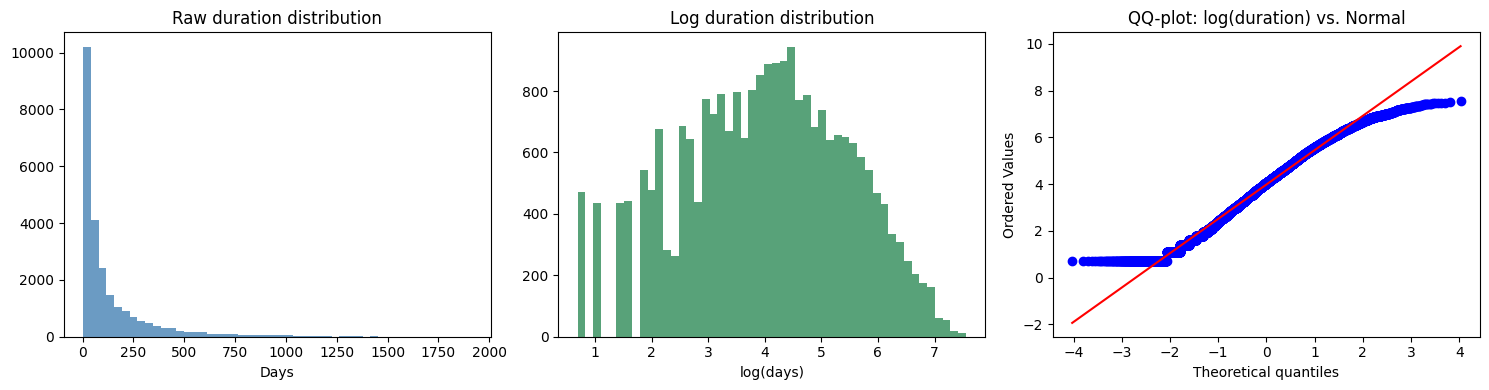

Skewness of log(duration): -0.144  (|<0.5| = approximately normal)
Kurtosis of log(duration): -0.632  (negative = slightly flat-tailed)


In [8]:
# Duration Distribution Check
closed_durations = df_surv.loc[
    (df_surv["event"] == 1) & (df_surv["duration"] > 0),
    "duration"
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(closed_durations, bins=50, color="steelblue", alpha=0.8)
axes[0].set_title("Raw duration distribution")
axes[0].set_xlabel("Days")

axes[1].hist(np.log(closed_durations), bins=50, color="seagreen", alpha=0.8)
axes[1].set_title("Log duration distribution")
axes[1].set_xlabel("log(days)")

stats.probplot(np.log(closed_durations), dist="norm", plot=axes[2])
axes[2].set_title("QQ-plot: log(duration) vs. Normal")

plt.tight_layout()
plt.show()

skew = np.log(closed_durations).skew()
kurt = np.log(closed_durations).kurt()
print(f"Skewness of log(duration): {skew:.3f}  (|<0.5| = approximately normal)")
print(f"Kurtosis of log(duration): {kurt:.3f}  (negative = slightly flat-tailed)")

## 2. Temporal train / validation / test split

In [9]:
TRAIN_END = pd.Timestamp("2024-12-31")
VAL_END   = pd.Timestamp("2025-06-30")

# Closed deals: split by closed_dt
# Open deals: go into training as censored observations (registered before 2025)
is_closed = df_surv["event"] == 1

train_mask = (is_closed & (df_surv["closed_dt"] <= TRAIN_END)) | (~is_closed & (df_surv["registered_dt"] <= TRAIN_END))
val_mask   = is_closed & (df_surv["closed_dt"] > TRAIN_END) & (df_surv["closed_dt"] <= VAL_END)
test_mask  = is_closed & (df_surv["closed_dt"] > VAL_END)

df_train = df_surv[train_mask].copy()
df_val   = df_surv[val_mask].copy()
df_test  = df_surv[test_mask].copy()

print(f"{'Set':<8} {'Total':>7} {'Events':>7} {'Censored':>9} {'Event%':>7}")
print("-" * 42)
for name, split in [("Train", df_train), ("Val", df_val), ("Test", df_test)]:
    n = len(split)
    e = split["event"].sum()
    c = n - e
    print(f"{name:<8} {n:>7,} {e:>7,} {c:>9,} {e/n*100:>6.1f}%")

Set        Total  Events  Censored  Event%
------------------------------------------
Train     24,390  20,253     4,137   83.0%
Val        2,011   2,011         0  100.0%
Test       2,374   2,374         0  100.0%


## 3. Feature Selection

### Feature Justification

All features are derived from `df_cph_ready.parquet` which incorporates filtering,
feature engineering, and leakage controls from KM/CPH analysis.

#### Feature Groups

| Feature | Group | Evidence |
|:---|:---|:---|
| `prob_init` | Creation | CPH HR=1.96; KM: weak but consistent signal |
| `prob_is_default` | Creation | 41.6% of deals at system default (0.1099) |
| `log_amount` | Creation | KM: monotonic — larger deals close slower |
| `stage_merged` | Creation | CPH HR=7.1 (Late vs Early); strong at creation |
| `has_products_and_services` | Creation | CPH HR=1.47; consistent across all models |
| `business_unit` | Creation | KM: p<0.001; one BU clear outlier (68.5% rate) |
| `org_category_merged` | Creation | KM: Partner/ECO-Partner close 2–3x faster |
| `chance_type_en` | Creation | KM: significant; Partner Opportunity HR=0.34 |
| `home_country` | Creation | KM: significant; attenuated in full CPH |
| `intercompany_flag` | Creation | CPH HR=0.60; internal deals 40% slower |
| `rep_closing_rate` | Creation | CPH HR=2.2; stratified due to PH violation |
| `rep_no_prior_closes` | Creation | Structural outlier: 12.2% event rate |
| `log_rep_amount` | Creation | KM: threshold at 100 deals; HR=0.98 |
| `log_deal_share_rep` | Creation | CPH HR=1.67; priority deals close faster |
| `prob_last_open` | Current state | CPH HR=2.02; stronger than `prob_init` |
| `prob_last_open_is_default` | Current state | 32% of deals still at default at last open entry |
| `stage_last_open_merged` | Current state | CPH HR=1.53 (Mid), 1.31 (Late); better than init |
| `resp_change` | Current state | CPH HR=0.67; complexity proxy, not causal |
| `days_since_last_update` | Current state | KM: strong separation; activity signal |
| `amount_changes` | Current state | KM: 4+ changes → significantly slower closure |
| `close_date_shift` | CRM flagged | Strong KM signal conditional on `saledate_ever_updated` |
| `saledate_ever_updated` | CRM flagged | Conditioning flag — separates CRM updaters from non-updaters |
| `total_days_pushed` | CRM flagged | Complexity signal conditional on `saledate_ever_updated` |

#### Excluded Features

| Feature | Reason |
|:---|:---|
| `days_until_saledate` | Manually entered, rarely updated — negative values reflect CRM hygiene failures not deal timing |
| `customer_win_ratio` | Not available in current dataset |
| `is_repeat_customer` | Not available in current dataset |
| `zombie_deal` | Filtered out upstream in `df_cph_ready.parquet` |
| `deal_age` | Redundant with duration |
| `target_won` | Outcome variable, not a feature |
| `updates_last_*` | Not analyzed — add in future iteration if needed |

In [10]:
# Feature sets
CREATION_FEATURES = [
    "prob_init",
    "prob_is_default",
    "log_amount",
    "stage_merged",
    "has_products_and_services",
    "business_unit",
    "org_category_merged",
    "chance_type_en",
    "home_country",
    "intercompany_flag",
    "rep_closing_rate",
    "rep_no_prior_closes",
    "log_rep_amount",
    "log_deal_share_rep",
]

CURRENT_STATE_FEATURES = [
    "prob_last_open",
    "prob_last_open_is_default",
    "stage_last_open_merged",
    "resp_change",
    "days_since_last_update",
    "amount_changes",
]

CRM_FLAGGED_FEATURES = [
    "close_date_shift",
    "saledate_ever_updated",
    "total_days_pushed",
]

FEATURES = CREATION_FEATURES + CURRENT_STATE_FEATURES + CRM_FLAGGED_FEATURES

print(f"Creation features:      {len(CREATION_FEATURES)}")
print(f"Current state features: {len(CURRENT_STATE_FEATURES)}")
print(f"CRM flagged features:   {len(CRM_FLAGGED_FEATURES)}")
print(f"Total features:         {len(FEATURES)}")
print(f"\nNaN check:")
print(df_surv[FEATURES].isna().sum())

Creation features:      14
Current state features: 6
CRM flagged features:   3
Total features:         23

NaN check:
prob_init                      0
prob_is_default                0
log_amount                     0
stage_merged                   0
has_products_and_services      0
business_unit                  0
org_category_merged            0
chance_type_en                 0
home_country                   0
intercompany_flag              0
rep_closing_rate               0
rep_no_prior_closes            0
log_rep_amount                 0
log_deal_share_rep             0
prob_last_open               386
prob_last_open_is_default      0
stage_last_open_merged       386
resp_change                    0
days_since_last_update         0
amount_changes                 0
close_date_shift               0
saledate_ever_updated          0
total_days_pushed              0
dtype: int64


## 4. Prepare X / y arrays for scikit-survival

In [11]:
# Smart filtering: define prediction bucket
    # Uncomment the bucket you want to train on.
    # Use label columns for readability — encoded columns still used in FEATURES.

# Option A — by Business Unit
# BUCKET_COL   = "business_unit_label"
# BUCKET_VALUE = "6befd145c261113d"

# Option B — by Org Category
# BUCKET_COL   = "org_category_merged"
# BUCKET_VALUE = "Partner"

# Option C — by Stage at last open observation
# BUCKET_COL   = "stage_last_open_merged"
# BUCKET_VALUE = "Late"

# Option D — by Chance Type
# BUCKET_COL   = "chance_type_en"
# BUCKET_VALUE = "General sale"

# Option E — no filtering (full dataset)
BUCKET_COL, BUCKET_VALUE = None, None

# Apply
if BUCKET_COL is not None:
    if isinstance(BUCKET_VALUE, list):
        bucket_mask = df_surv[BUCKET_COL].isin(BUCKET_VALUE)
    else:
        bucket_mask = df_surv[BUCKET_COL] == BUCKET_VALUE
    df_surv = df_surv[bucket_mask].reset_index(drop=True)
    print(f"Bucket: {BUCKET_COL} = {BUCKET_VALUE}")
    print(f"Remaining: {len(df_surv):,} deals")
else:
    print("No bucket filter applied — using full dataset")
    print(f"Total: {len(df_surv):,} deals")

No bucket filter applied — using full dataset
Total: 30,178 deals


In [12]:
# Re-apply temporal split on df_surv
is_closed = df_surv["event"] == 1

train_mask = (is_closed & (df_surv["closed_dt"] <= TRAIN_END)) | (~is_closed & (df_surv["registered_dt"] <= TRAIN_END))
val_mask   = is_closed & (df_surv["closed_dt"] > TRAIN_END) & (df_surv["closed_dt"] <= VAL_END)
test_mask  = is_closed & (df_surv["closed_dt"] > VAL_END)

# Drop rows with missing feature values
# 386 deals have no last open observation (went straight to Won/Lost)
# These are missing prob_last_open, stage_last_open_merged — drop them
before = len(df_surv)
df_surv = df_surv.dropna(subset=FEATURES).reset_index(drop=True)
print(f"Dropped {before - len(df_surv):,} rows (missing feature values)")

# Rebuild masks after dropna
is_closed = df_surv["event"] == 1

train_mask = (is_closed & (df_surv["closed_dt"] <= TRAIN_END)) | (~is_closed & (df_surv["registered_dt"] <= TRAIN_END))
val_mask   = is_closed & (df_surv["closed_dt"] > TRAIN_END) & (df_surv["closed_dt"] <= VAL_END)
test_mask  = is_closed & (df_surv["closed_dt"] > VAL_END)

# Encode categoricals for tree models
cat_cols = ["stage_merged", "stage_last_open_merged", "business_unit",
            "org_category_merged", "chance_type_en", "amount_change_bucket"]

enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
df_surv[cat_cols] = enc.fit_transform(df_surv[cat_cols].astype(str))
df_surv[cat_cols] = df_surv[cat_cols].astype(int)

# Feature matrix
X_train = df_surv.loc[train_mask, FEATURES]
X_val   = df_surv.loc[val_mask,   FEATURES]
X_test  = df_surv.loc[test_mask,  FEATURES]

# Structured target: (event_as_bool, duration)
# Event must be bool for scikit-survival
df_surv["event_bool"] = df_surv["event"].astype(bool)

y_train = Surv.from_dataframe("event_bool", "duration", df_surv.loc[train_mask])
y_val   = Surv.from_dataframe("event_bool", "duration", df_surv.loc[val_mask])
y_test  = Surv.from_dataframe("event_bool", "duration", df_surv.loc[test_mask])

print(f"\n{'Set':<6} {'Total':>7} {'Events':>7} {'Censored':>9}")
print("-" * 34)
for name, X, y in [("Train", X_train, y_train), ("Val", X_val, y_val), ("Test", X_test, y_test)]:
    e = sum(yi[0] for yi in y)
    print(f"{name:<6} {len(X):>7,} {e:>7,} {len(X)-e:>9,}")

print(f"\ny_train sample:\n{y_train[:5]}")

Dropped 386 rows (missing feature values)

Set      Total  Events  Censored
----------------------------------
Train   24,004  19,867     4,137
Val      2,011   2,011         0
Test     2,374   2,374         0

y_train sample:
[(False, 424.) (False, 406.) (False, 565.) (False, 664.) (False, 429.)]


##### Note:
- Deals with no last open observation were excluded
- Val and Test only contain closed deals since we evaluate on known outcomes
- y_train sample shows False (censored) with large durations: These are open deals that have been active for 400–600+ days. This is correct and expected. They're contributing useful information about long-running deals.

In [13]:
# Sanity check: duration distribution

train_df = df_surv.loc[train_mask]

print("Check for chances where duration = 0 days:")
print(f"  Total:    {(train_df['duration'] == 0).sum():,} of {len(train_df):,} ({(train_df['duration'] == 0).mean():.1%})")
print(f"  Censored: {((train_df['duration'] == 0) & (train_df['event'] == 0)).sum():,}")
print(f"  Events:   {((train_df['duration'] == 0) & (train_df['event'] == 1)).sum():,}")

print(f"\ny_train event distribution:")
print(f"  True (closed):  {sum(y[0] for y in y_train):,}")
print(f"  False (censor): {sum(not y[0] for y in y_train):,}")

print(f"\nDuration percentiles (Train):")
print(train_df["duration"].describe())

Check for chances where duration = 0 days:
  Total:    3,179 of 24,004 (13.2%)
  Censored: 3,178
  Events:   1

y_train event distribution:
  True (closed):  19,867
  False (censor): 4,137

Duration percentiles (Train):
count    24004.000000
mean       124.227337
std        203.680662
min          0.000000
25%          9.000000
50%         43.000000
75%        142.000000
max       2386.000000
Name: duration, dtype: float64


**Note: Negative Durations** 

One deal (`aade1524f54b0570`) was found with duration = -8 days, caused by `closed_dt` being 8 days before `registered_dt`, a backdated data entry error. Clipped to 0 upstream and removed by the duration filter in the drop mask.

### Rep Deal Count Lower Bound & Duration Min Filter (for Censored and Closed Deals)

In [14]:
# Clean data: remove uninformative observations
    # Note: zombie deals and amount filter already applied upstream in df_cph_ready.parquet

before = len(df_surv)

rep_lower_bound = 10
duration_min    = 3

# Rep deal count — only count closed deals
rep_closed_counts = (df_surv[df_surv["event"] == 1]
                       .groupby("responsible")["chance_id"]
                       .nunique())
low_volume_reps = rep_closed_counts[rep_closed_counts < rep_lower_bound].index

drop_mask = (
    ((df_surv["event"] == 0) & (df_surv["duration"] <= duration_min)) |  # uninformative censored
    ((df_surv["event"] == 1) & (df_surv["duration"] <= duration_min)) |  # closes within 3 days
    (df_surv["responsible"].isin(low_volume_reps))                        # rep with < 10 closed deals
)

df_surv = df_surv[~drop_mask].reset_index(drop=True)
print(f"Before: {before:,} deals")
print(f"Dropped: {drop_mask.sum():,} deals")
print(f"Remaining: {len(df_surv):,}")

Before: 29,792 deals
Dropped: 4,817 deals
Remaining: 24,975


In [15]:
# Rebuild X / y after filtering
is_closed = df_surv["event"] == 1

train_mask = (is_closed & (df_surv["closed_dt"] <= TRAIN_END)) | (~is_closed & (df_surv["registered_dt"] <= TRAIN_END))
val_mask   = is_closed & (df_surv["closed_dt"] > TRAIN_END) & (df_surv["closed_dt"] <= VAL_END)
test_mask  = is_closed & (df_surv["closed_dt"] > VAL_END)

X_train = df_surv.loc[train_mask, FEATURES]
X_val   = df_surv.loc[val_mask,   FEATURES]
X_test  = df_surv.loc[test_mask,  FEATURES]

y_train = Surv.from_dataframe("event_bool", "duration", df_surv.loc[train_mask])
y_val   = Surv.from_dataframe("event_bool", "duration", df_surv.loc[val_mask])
y_test  = Surv.from_dataframe("event_bool", "duration", df_surv.loc[test_mask])

print(f"\n{'Set':<6} {'Total':>7} {'Events':>7} {'Censored':>9}")
print("-" * 34)
for name, X, y in [("Train", X_train, y_train), ("Val", X_val, y_val), ("Test", X_test, y_test)]:
    e = sum(yi[0] for yi in y)
    print(f"{name:<6} {len(X):>7,} {e:>7,} {len(X)-e:>9,}")


Set      Total  Events  Censored
----------------------------------
Train   19,977  19,123       854
Val      1,873   1,873         0
Test     2,230   2,230         0


## 5. Gradient Boosting Survival Analysis

In [16]:
# Baseline model with conservative hyperparameters
gbsa = GradientBoostingSurvivalAnalysis(
    n_estimators=50,
    learning_rate=0.2,
    max_depth=2,
    min_samples_split=100,
    min_samples_leaf=50,
    subsample=0.5,
    random_state=42,
)

gbsa.fit(X_train, y_train)

results = {}
for name, X, y in [("Train", X_train, y_train), ("Val", X_val, y_val), ("Test", X_test, y_test)]:
    risk = gbsa.predict(X)
    ci = concordance_index_censored(y["event_bool"], y["duration"], risk)
    results[name] = ci[0]
    print(f"{name:<6} C-Index: {ci[0]:.4f}")

print(f"\nCPH baseline was: 0.631 (Creation features only [Fair comparison])")

Train  C-Index: 0.8603
Val    C-Index: 0.8691
Test   C-Index: 0.8538

CPH baseline was: 0.631 (Creation features only [Fair comparison])


## 6. Random Survival Forest

In [17]:
# RSF builds many decision trees on random feature subsets and averages the survival functions. 
# Advantage: no subsampling needed, robust against overfitting, directly delivers survival curves per deal.
rsf = RandomSurvivalForest(
    n_estimators=100,
    max_features="sqrt",       # Standard for RSF
    min_samples_leaf=15,       # Minimum leaf size → stability
    n_jobs=-1,                 # Use all CPU cores
    random_state=42,
)

rsf.fit(X_train, y_train)

print("\nResults:")
print(f"{'Model':<22} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 50)

for name, model in [("GBSA (50 trees, sub)", gbsa), ("RSF (100 trees, full)", rsf)]:
    row = []
    for X, y in [(X_train, y_train), (X_val, y_val), (X_test, y_test)]:
        risk = model.predict(X)
        ci = concordance_index_censored(y["event_bool"], y["duration"], risk)[0]
        row.append(ci)
    print(f"{name:<22} {row[0]:>8.4f} {row[1]:>8.4f} {row[2]:>8.4f}")

print(f"\nCPH Baseline:          {'–':>8} {'0.631':>8} {'–':>8}")


Results:
Model                     Train      Val     Test
--------------------------------------------------
GBSA (50 trees, sub)     0.8603   0.8691   0.8538
RSF (100 trees, full)    0.8282   0.8285   0.8044

CPH Baseline:                 –    0.631        –


## 7. XGBoost – Cox Proportional Hazards

In [18]:
# XGBoost with survival:cox minimises the Cox Partial Likelihood.
#   Label encoding: positive values = Event (duration), negative = censored (-duration).
#   Advantages: all samples, early stopping, much faster than GBSA.
def make_xgb_labels(y_surv):
    """Convert sksurv structured array into XGBoost Cox labels."""
    labels = np.where(
        y_surv["event_bool"],
        y_surv["duration"],   # Event: positive
        -y_surv["duration"],  # Censored: negative
    ).astype(np.float32)
    return labels

dtrain = xgb.DMatrix(X_train.values, label=make_xgb_labels(y_train), feature_names=FEATURES)
dval   = xgb.DMatrix(X_val.values,   label=make_xgb_labels(y_val),   feature_names=FEATURES)
dtest  = xgb.DMatrix(X_test.values,  label=make_xgb_labels(y_test),  feature_names=FEATURES)

# Training with Early Stopping
params = {
    "objective":       "survival:cox",
    "eval_metric":     "cox-nloglik",
    "learning_rate":   0.05,
    "max_depth":       4,
    "subsample":       0.8,
    "colsample_bytree":0.8,
    "min_child_weight":20,
    "seed":            42,
}

xgb_cox = xgb.train(
    params,
    dtrain,
    num_boost_round=500,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds=30,
    verbose_eval=50,
)

# C-Index evaluation
print(f"\nBest iteration: {xgb_cox.best_iteration}")
print(f"\n{'Model':<25} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 53)

# XGBoost predict() returns log-hazard → higher = closes faster → correct direction for C-Index
for name, model in [("GBSA (50 trees)", gbsa), ("RSF (100 trees)", rsf)]:
    row = []
    for X, y in [(X_train, y_train), (X_val, y_val), (X_test, y_test)]:
        ci = concordance_index_censored(y["event_bool"], y["duration"], model.predict(X))[0]
        row.append(ci)
    print(f"{name:<25} {row[0]:>8.4f} {row[1]:>8.4f} {row[2]:>8.4f}")

row_xgb = []
for dmat, y in [(dtrain, y_train), (dval, y_val), (dtest, y_test)]:
    risk = xgb_cox.predict(dmat)
    ci = concordance_index_censored(y["event_bool"], y["duration"], risk)[0]
    row_xgb.append(ci)
print(f"{'XGBoost Cox':<25} {row_xgb[0]:>8.4f} {row_xgb[1]:>8.4f} {row_xgb[2]:>8.4f}")
print(f"\n{'CPH Baseline':<25} {'–':>8} {'0.631':>8} {'–':>8}")


[0]	train-cox-nloglik:8.88279	val-cox-nloglik:6.49338
[50]	train-cox-nloglik:8.31474	val-cox-nloglik:5.90262
[100]	train-cox-nloglik:8.20224	val-cox-nloglik:5.78491
[150]	train-cox-nloglik:8.15011	val-cox-nloglik:5.73649
[200]	train-cox-nloglik:8.11705	val-cox-nloglik:5.71235
[250]	train-cox-nloglik:8.09233	val-cox-nloglik:5.69723
[300]	train-cox-nloglik:8.07276	val-cox-nloglik:5.68772
[350]	train-cox-nloglik:8.05578	val-cox-nloglik:5.67690
[383]	train-cox-nloglik:8.04456	val-cox-nloglik:5.67821

Best iteration: 353

Model                        Train      Val     Test
-----------------------------------------------------
GBSA (50 trees)             0.8603   0.8691   0.8538
RSF (100 trees)             0.8282   0.8285   0.8044
XGBoost Cox                 0.8792   0.8830   0.8675

CPH Baseline                     –    0.631        –


## 8. XGBoost – Accelerated Failure Time (AFT)

In [19]:
# AFT directly predicts the time to close (in days).
    # Censored deals are modelled as interval [duration, +inf).
    # Advantage over Cox: delivers absolute time estimates → predicted_close_date.

# Label format: DMatrix with label_lower_bound / label_upper_bound
    # Event:    lower = upper = duration  (exact time point known)
    # Censored: lower = duration, upper = +inf  (only 'at least' known)

def make_aft_bounds(y_surv):
    duration = y_surv["duration"].astype(float)
    lower = duration.copy()
    upper = np.where(y_surv["event_bool"], duration, np.inf)
    return lower.astype(np.float32), upper.astype(np.float32)

def make_aft_dmatrix(X, y_surv, feature_names):
    lower, upper = make_aft_bounds(y_surv)
    dm = xgb.DMatrix(X.values, feature_names=feature_names)
    dm.set_float_info("label_lower_bound", lower)
    dm.set_float_info("label_upper_bound", upper)
    return dm

dtrain_aft = make_aft_dmatrix(X_train, y_train, FEATURES)
dval_aft   = make_aft_dmatrix(X_val,   y_val,   FEATURES)
dtest_aft  = make_aft_dmatrix(X_test,  y_test,  FEATURES)

# Training
params_aft = {
    "objective":              "survival:aft",
    "eval_metric":            "aft-nloglik",
    "aft_loss_distribution":  "normal",  # log(duration) is approximately normal -> justifies AFT with 'normal' distribution
    "aft_loss_distribution_scale": 1.0,
    "learning_rate":          0.05,
    "max_depth":              4,
    "subsample":              0.8,
    "colsample_bytree":       0.8,
    "min_child_weight":       20,
    "seed":                   42,
}

xgb_aft = xgb.train(
    params_aft,
    dtrain_aft,
    num_boost_round=500,
    evals=[(dtrain_aft, "train"), (dval_aft, "val")],
    early_stopping_rounds=30,
    verbose_eval=50,
)

# C-Index evaluation
# AFT outputs log(predicted_time) → higher time = lower risk → negate for C-Index
print(f"\nBest iteration: {xgb_aft.best_iteration}")

print(f"\n{'Model':<25} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 53)

for name, model in [("GBSA (50 trees)", gbsa), ("RSF (100 trees)", rsf)]:
    row = [concordance_index_censored(y["event_bool"], y["duration"], model.predict(X))[0]
           for X, y in [(X_train, y_train), (X_val, y_val), (X_test, y_test)]]
    print(f"{name:<25} {row[0]:>8.4f} {row[1]:>8.4f} {row[2]:>8.4f}")

for name, model, sets in [
    ("XGBoost Cox",  xgb_cox, [(dtrain, y_train), (dval, y_val), (dtest, y_test)]),
    ("XGBoost AFT",  xgb_aft, [(dtrain_aft, y_train), (dval_aft, y_val), (dtest_aft, y_test)]),
]:
    row = []
    for dm, y in sets:
        pred = xgb_aft.predict(dm) if name == "XGBoost AFT" else xgb_cox.predict(dm)
        # AFT: predicted time → higher = open longer = lower risk → negate
        risk = -pred if name == "XGBoost AFT" else pred
        row.append(concordance_index_censored(y["event_bool"], y["duration"], risk)[0])
    print(f"{name:<25} {row[0]:>8.4f} {row[1]:>8.4f} {row[2]:>8.4f}")

print(f"\n{'CPH Baseline':<25} {'–':>8} {'0.631':>8} {'–':>8}")

[0]	train-aft-nloglik:16.04732	val-aft-nloglik:16.18940
[50]	train-aft-nloglik:5.10920	val-aft-nloglik:5.32439
[100]	train-aft-nloglik:5.01029	val-aft-nloglik:5.22186
[150]	train-aft-nloglik:4.99850	val-aft-nloglik:5.21412
[200]	train-aft-nloglik:4.99101	val-aft-nloglik:5.20971
[250]	train-aft-nloglik:4.98618	val-aft-nloglik:5.20719
[300]	train-aft-nloglik:4.98132	val-aft-nloglik:5.20583
[350]	train-aft-nloglik:4.97743	val-aft-nloglik:5.20493
[400]	train-aft-nloglik:4.97390	val-aft-nloglik:5.20391
[450]	train-aft-nloglik:4.97079	val-aft-nloglik:5.20338
[499]	train-aft-nloglik:4.96771	val-aft-nloglik:5.20305

Best iteration: 494

Model                        Train      Val     Test
-----------------------------------------------------
GBSA (50 trees)             0.8603   0.8691   0.8538
RSF (100 trees)             0.8282   0.8285   0.8044
XGBoost Cox                 0.8792   0.8830   0.8675
XGBoost AFT                 0.8926   0.8865   0.8744

CPH Baseline                     –    0.631

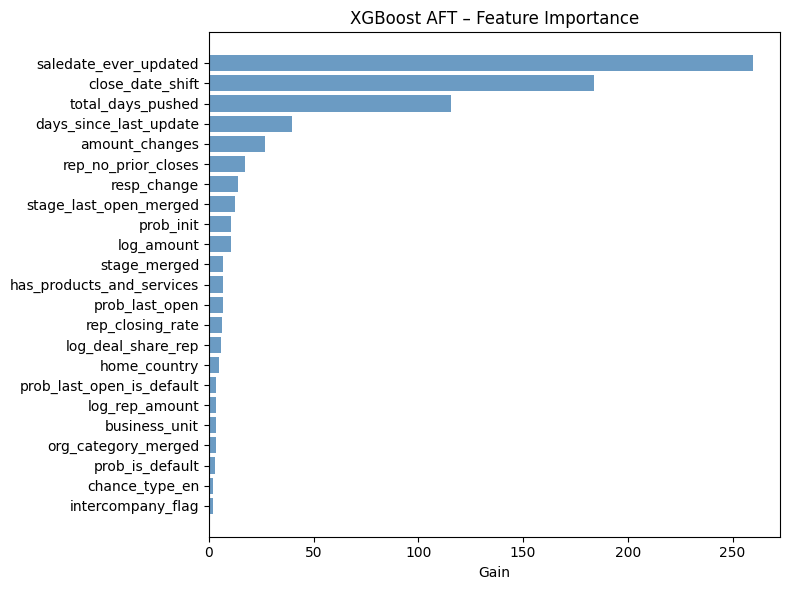

In [20]:
# Feature importance from XGBoost AFT
importance = xgb_aft.get_score(importance_type="gain")  # or "weight", "cover"
importance_df = (pd.DataFrame.from_dict(importance, orient="index", columns=["importance"])
                   .sort_values("importance", ascending=True))

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(importance_df.index, importance_df["importance"], color="steelblue", alpha=0.8)
ax.set_xlabel("Gain")
ax.set_title("XGBoost AFT – Feature Importance")
plt.tight_layout()
plt.show()

### Feature Importance — XGBoost AFT

The gain-based feature importance reveals a clear hierarchy across the three feature groups:

**CRM-flagged features dominate** — `saledate_ever_updated`, `close_date_shift`, and
`total_days_pushed` are the top three features by a large margin. This is consistent
with their strong KM signal but warrants a production caveat: for reps who never update
the saledate field, all three features are 0 by default, meaning the model partially
predicts CRM discipline rather than genuine deal dynamics for those deals. The
`saledate_ever_updated` conditioning flag is therefore not just a statistical control —
it is the single most informative feature in the model.

**Current state features** — `days_since_last_update` and `amount_changes` are the
strongest non-CRM predictors, followed by `rep_no_prior_closes` and `resp_change`.
These features reflect deal activity and complexity as they stand at prediction time,
confirming that current state adds meaningful signal beyond creation-time information.

**Creation-time features** — `prob_init`, `log_amount`, and `stage_merged` contribute
modestly but consistently. Notably, `prob_last_open` ranks below `prob_init` in gain
importance despite showing a stronger hazard ratio in CPH (HR 2.02 vs 1.96). This
discrepancy is expected — gain importance and hazard ratios measure fundamentally
different things. Gain reflects how much a feature reduces prediction error in the
tree splits; HR reflects the marginal effect on the hazard holding other features
constant. Both are valid perspectives on feature relevance.

**Bottom features** — `intercompany_flag`, `chance_type_en`, `prob_is_default`,
`org_category_merged`, and `business_unit` contribute the least gain. This does not
mean they are unimportant — they may still improve predictions for specific deal
subgroups even if their average gain is low.

## 9. DeepSurv (not feasible)
DeepSurv (MLP + Cox) was evaluated for the sake of completeness, but training took over 110 minutes.

On tabular data with 15 features and our depth, it generally offers no advantage over gradient boosting.

→ Will not be pursued further for this use case.

## 10. Model Comparisson

In [22]:
print(f"\n{'Model':<25} {'Train':>8} {'Val':>8} {'Test':>8}")
print("=" * 53)
print(f"{'CPH Creation-only':<25} {'–':>8} {'0.631':>8} {'–':>8}")
print(f"{'CPH + Current state':<25} {'–':>8} {'0.711':>8} {'–':>8}")

model_results = {
    "GBSA (50 trees)":  (gbsa,    [(X_train, y_train), (X_val, y_val), (X_test, y_test)],    None),
    "RSF (100 trees)":  (rsf,     [(X_train, y_train), (X_val, y_val), (X_test, y_test)],    None),
    "XGBoost Cox":      (xgb_cox, [(dtrain, y_train),  (dval, y_val),  (dtest, y_test)],     False),
    "XGBoost AFT":      (xgb_aft, [(dtrain_aft, y_train), (dval_aft, y_val), (dtest_aft, y_test)], True),
}

all_val_scores = {}
for name, (model, sets, is_aft) in model_results.items():
    row = []
    for X_or_dm, y in sets:
        if is_aft is None:
            risk = model.predict(X_or_dm)
        elif is_aft:
            risk = -model.predict(X_or_dm)
        else:
            risk = model.predict(X_or_dm)
        row.append(concordance_index_censored(y["event_bool"], y["duration"], risk)[0])
    all_val_scores[name] = row[1]

best_val  = max(all_val_scores, key=all_val_scores.get)
for name, (model, sets, is_aft) in model_results.items():
    row = []
    for X_or_dm, y in sets:
        if is_aft is None:
            risk = model.predict(X_or_dm)
        elif is_aft:
            risk = -model.predict(X_or_dm)
        else:
            risk = model.predict(X_or_dm)
        row.append(concordance_index_censored(y["event_bool"], y["duration"], risk)[0])
    marker = " ◀" if name == best_val else ""
    print(f"{name:<25} {row[0]:>8.4f} {row[1]:>8.4f}{marker:<3} {row[2]:>8.4f}")
print(f"\n{'DeepSurv':<25} {'n.a.':>8} {'n.a.':>8}     {'n.a.':>8}  ← CPU not practical")


Model                        Train      Val     Test
CPH Creation-only                –    0.631        –
CPH + Current state              –    0.711        –
GBSA (50 trees)             0.8603   0.8691      0.8538
RSF (100 trees)             0.8282   0.8285      0.8044
XGBoost Cox                 0.8792   0.8830      0.8675
XGBoost AFT                 0.8926   0.8865 ◀    0.8744

DeepSurv                      n.a.     n.a.         n.a.  ← CPU not practical


### Model Comparison

All four models substantially outperform the CPH creation-only baseline (0.631),
confirming that the ML models with current-state features are capturing signal well
beyond what a linear model with creation-time features can achieve.

| Model | Train | Val | Test |
|---|---|---|---|
| CPH Creation-only baseline | — | 0.631 | — |
| CPH + Current state baseline | — | 0.711 | — |
| GBSA (50 trees) | 0.8603 | 0.8691 | 0.8538 |
| RSF (100 trees) | 0.8282 | 0.8285 | 0.8044 |
| XGBoost Cox | 0.8792 | 0.8830 | 0.8675 |
| **XGBoost AFT** | **0.8926** | **0.8865 ◀** | **0.8744** |
| DeepSurv | n.a. | n.a. | n.a. — CPU not practical |

**XGBoost AFT is selected** — best Val C-Index (0.8865) and delivers absolute time
predictions, which Cox cannot. Val and Test scores are close (0.8865 vs 0.8744),
confirming the model generalises well without overfitting.

The jump from CPH current-state baseline (0.711) to XGBoost AFT (0.8865) reflects the
advantage of gradient boosting over a linear model — non-linear interactions between
features, particularly between the CRM-flagged features and deal characteristics, are
captured by the tree model but not by CPH.

Note: the C-Index is used here for model selection only. The primary success criterion
for AFT is the Delta analysis in the next section — % exact quarter and % within
±1 quarter — which directly measures business-relevant prediction accuracy.Sonnet 4.6

## 11. Time Prediction with XGBoost AFT

In [23]:
# Eval set: Val + Test (both out-of-sample, all closed deals)
# AFT predict() directly outputs days to close (no exp() needed).

# Note for production use:
# For open deals, predicted_days represents total expected duration from registered_dt.
# To get expected days remaining, subtract deal age:
#   days_remaining = predicted_days - (today - registered_dt).days
# This gives the forward-looking prediction from today's date.

is_closed = df_surv["event"] == 1
val_mask  = is_closed & (df_surv["closed_dt"] > TRAIN_END) & (df_surv["closed_dt"] <= VAL_END)
test_mask = is_closed & (df_surv["closed_dt"] > VAL_END)
eval_mask = val_mask | test_mask

df_eval = df_surv[eval_mask].copy().reset_index(drop=True)
X_eval  = df_eval[FEATURES]

# DMatrix for AFT
dur_eval = df_eval["duration"].values.astype(np.float32)
dm_eval  = xgb.DMatrix(X_eval.values, feature_names=FEATURES)
dm_eval.set_float_info("label_lower_bound", dur_eval)
dm_eval.set_float_info("label_upper_bound",
    np.where(df_eval["event_bool"].values, dur_eval, np.inf).astype(np.float32))

# Predictions
predicted_days       = xgb_aft.predict(dm_eval)
predicted_close_date = df_eval["registered_dt"] + pd.to_timedelta(np.round(predicted_days).astype(int), unit="D")
actual_close_date    = df_eval["closed_dt"]

# Compute 9 columns
delta_days = (predicted_close_date - actual_close_date).dt.days

pred_week_num  = predicted_close_date.dt.isocalendar().week.astype(str).str.zfill(2)
act_week_num   = actual_close_date.dt.isocalendar().week.astype(str).str.zfill(2)
predicted_week = predicted_close_date.dt.year.astype(str) + "-W" + pred_week_num
actual_week    = actual_close_date.dt.year.astype(str)    + "-W" + act_week_num
delta_weeks    = (delta_days / 7).round().astype(int)

predicted_month = predicted_close_date.dt.to_period("M").astype(str)
actual_month    = actual_close_date.dt.to_period("M").astype(str)
delta_months    = ((predicted_close_date.dt.year  - actual_close_date.dt.year)  * 12 +
                   (predicted_close_date.dt.month - actual_close_date.dt.month))

predicted_quarter = predicted_close_date.dt.year.astype(str) + "-Q" + predicted_close_date.dt.quarter.astype(str)
actual_quarter    = actual_close_date.dt.year.astype(str)    + "-Q" + actual_close_date.dt.quarter.astype(str)
delta_quarters    = ((predicted_close_date.dt.year    - actual_close_date.dt.year)    * 4 +
                     (predicted_close_date.dt.quarter - actual_close_date.dt.quarter))

# Assemble & save DataFrame
df_predictions = pd.DataFrame({
    "chance_id":            df_eval["chance_id"].values,
    "predicted_close_date": predicted_close_date.values,
    "actual_close_date":    actual_close_date.values,
    "delta_days":           delta_days.values,
    "predicted_week":       predicted_week.values,
    "actual_week":          actual_week.values,
    "delta_weeks":          delta_weeks.values,
    "predicted_month":      predicted_month.values,
    "actual_month":         actual_month.values,
    "delta_months":         delta_months.values,
    "predicted_quarter":    predicted_quarter.values,
    "actual_quarter":       actual_quarter.values,
    "delta_quarters":       delta_quarters.values,
})
# df_predictions.to_csv("../data/tte_predictions.csv", index=False)

# Metrics
print(f"Eval set: {len(df_eval):,} deals (Val + Test, out-of-sample)")
print(f"\n{'Granularity':<12} {'Median |Δ|':>12} {'Bias (Median Δ)':>17} {'% exact':>12}")
print("-" * 57)
print(f"{'Days':<12} {delta_days.abs().median():>12.1f} {delta_days.median():>17.1f} {'–':>12}")
print(f"{'Weeks':<12} {delta_weeks.abs().median():>12.1f} {delta_weeks.median():>17.1f} {(delta_weeks==0).mean()*100:>11.1f}%")
print(f"{'Months':<12} {delta_months.abs().median():>12.1f} {delta_months.median():>17.1f} {(delta_months==0).mean()*100:>11.1f}%")
print(f"{'Quarters':<12} {delta_quarters.abs().median():>12.1f} {delta_quarters.median():>17.1f} {(delta_quarters==0).mean()*100:>11.1f}%")
print(f"\nSaved: ../data/tte_predictions.csv")
df_predictions.head()


Eval set: 4,103 deals (Val + Test, out-of-sample)

Granularity    Median |Δ|   Bias (Median Δ)      % exact
---------------------------------------------------------
Days                 16.0              -1.0            –
Weeks                 2.0               0.0        20.5%
Months                1.0               0.0        44.5%
Quarters              0.0               0.0        68.0%

Saved: ../data/tte_predictions.csv


,chance_id,predicted_close_date,actual_close_date,delta_days,predicted_week,actual_week,delta_weeks,predicted_month,actual_month,delta_months,predicted_quarter,actual_quarter,delta_quarters
0,389db7faa4d5957d,2026-04-11 12:23:46,2026-01-05 16:14:34,95,2026-W15,2026-W02,14,2026-04,2026-01,3,2026-Q2,2026-Q1,1
1,4aa8503e724ab088,2026-01-12 14:03:55,2026-01-05 15:16:19,6,2026-W03,2026-W02,1,2026-01,2026-01,0,2026-Q1,2026-Q1,0
2,1408f565a3c965dd,2026-01-22 21:20:33,2026-01-05 14:04:15,17,2026-W04,2026-W02,2,2026-01,2026-01,0,2026-Q1,2026-Q1,0
3,e8c9264ea25ebbdf,2025-12-25 15:45:59,2026-01-05 13:50:19,-11,2025-W52,2026-W02,-2,2025-12,2026-01,-1,2025-Q4,2026-Q1,-1
4,40c3d53276585bc4,2026-02-19 10:55:21,2025-12-19 10:45:19,62,2026-W08,2025-W51,9,2026-02,2025-12,2,2026-Q1,2025-Q4,1


In [24]:
df_predictions["delta_days"].describe()

count    4103.000000
mean       -9.237875
std        86.158432
min      -983.000000
25%       -21.000000
50%        -1.000000
75%        12.000000
max       849.000000
Name: delta_days, dtype: float64

In [25]:
df_predictions["delta_days"].idxmax()

2547

In [26]:
df_predictions.iloc[[2547]]

,chance_id,predicted_close_date,actual_close_date,delta_days,predicted_week,actual_week,delta_weeks,predicted_month,actual_month,delta_months,predicted_quarter,actual_quarter,delta_quarters
2547,6f93208c3c508848,2027-10-08 09:24:35,2025-06-10 13:29:48,849,2027-W40,2025-W24,121,2027-10,2025-06,28,2027-Q4,2025-Q2,10


In [27]:
df_predictions["delta_days"].idxmin()

2219

In [28]:
df_predictions.iloc[[2219]]

,chance_id,predicted_close_date,actual_close_date,delta_days,predicted_week,actual_week,delta_weeks,predicted_month,actual_month,delta_months,predicted_quarter,actual_quarter,delta_quarters
2219,9118630ea9b3f8ac,2022-10-29 10:59:31,2025-07-07 13:12:20,-983,2022-W43,2025-W28,-140,2022-10,2025-07,-33,2022-Q4,2025-Q3,-11


## 12. Visualization

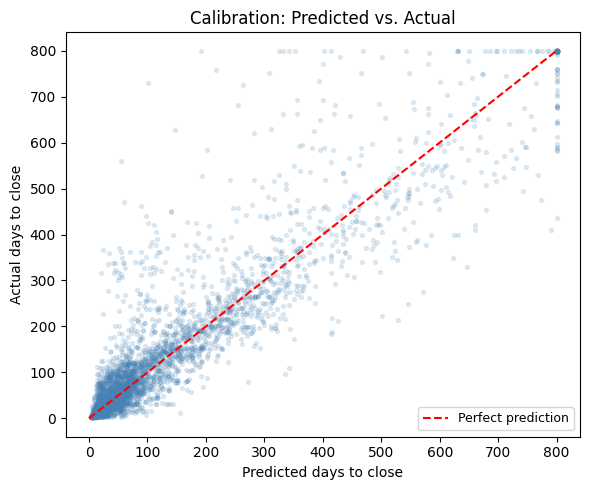

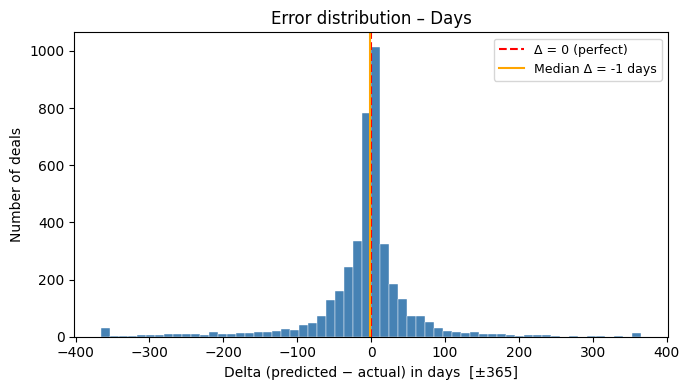

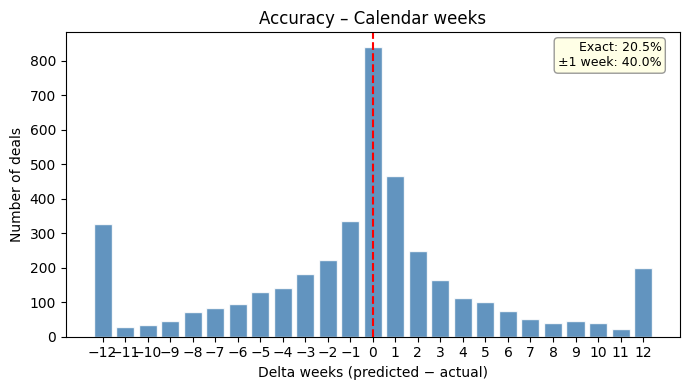

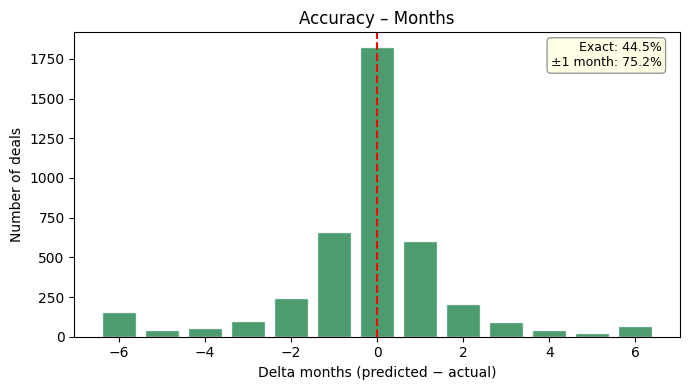

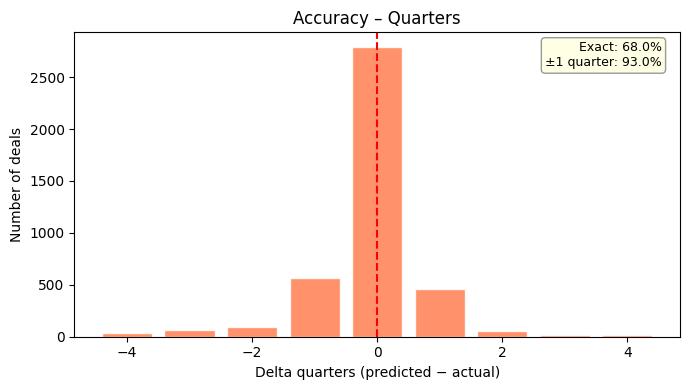

In [30]:
# Helper: accuracy summary box
def accuracy_box(ax, series, unit, clip):
    exact  = (series == 0).mean() * 100
    within1 = (series.abs() <= 1).mean() * 100
    ax.text(0.97, 0.97, f"Exact: {exact:.1f}%\n±1 {unit}: {within1:.1f}%",
            transform=ax.transAxes, va="top", ha="right", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", ec="gray", alpha=0.8))

# (A) Calibration plot
fig, ax = plt.subplots(figsize=(6, 5))
act_days = (actual_close_date - df_eval["registered_dt"]).dt.days.values
clip = 800
ax.scatter(np.clip(predicted_days, 0, clip), np.clip(act_days, 0, clip),
           alpha=0.15, s=8, color="steelblue")
ax.plot([0, clip], [0, clip], "r--", lw=1.5, label="Perfect prediction")
ax.set_xlabel("Predicted days to close")
ax.set_ylabel("Actual days to close")
ax.set_title("Calibration: Predicted vs. Actual")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# (B) Delta Days
fig, ax = plt.subplots(figsize=(7, 4))
delta_clipped = df_predictions["delta_days"].clip(-365, 365)
ax.hist(delta_clipped, bins=60, color="steelblue", edgecolor="white", linewidth=0.3)
ax.axvline(0, color="red", linestyle="--", lw=1.5, label="Δ = 0 (perfect)")
ax.axvline(df_predictions["delta_days"].median(), color="orange", lw=1.5,
           label=f"Median Δ = {df_predictions['delta_days'].median():.0f} days")
ax.set_xlabel("Delta (predicted − actual) in days  [±365]")
ax.set_ylabel("Number of deals")
ax.set_title("Error distribution – Days")
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# (C) Delta Weeks
fig, ax = plt.subplots(figsize=(7, 4))
vals = df_predictions["delta_weeks"].astype(int).clip(-12, 12)
counts = vals.value_counts().sort_index()
ax.bar(counts.index, counts.values, color="steelblue", alpha=0.85, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", lw=1.5)
ax.set_xticks(range(-12, 13))
ax.set_xlabel("Delta weeks (predicted − actual)")
ax.set_ylabel("Number of deals")
ax.set_title("Accuracy – Calendar weeks")
accuracy_box(ax, df_predictions["delta_weeks"], "week", 12)
plt.tight_layout(); plt.show()

# (D) Delta Months
fig, ax = plt.subplots(figsize=(7, 4))
vals = df_predictions["delta_months"].astype(int).clip(-6, 6)
counts = vals.value_counts().sort_index()
ax.bar(counts.index, counts.values, color="seagreen", alpha=0.85, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", lw=1.5)
ax.set_xlabel("Delta months (predicted − actual)")
ax.set_ylabel("Number of deals")
ax.set_title("Accuracy – Months")
accuracy_box(ax, df_predictions["delta_months"], "month", 6)
plt.tight_layout(); plt.show()

# (E) Delta Quarters
fig, ax = plt.subplots(figsize=(7, 4))
vals = df_predictions["delta_quarters"].astype(int).clip(-4, 4)
counts = vals.value_counts().sort_index()
ax.bar(counts.index, counts.values, color="coral", alpha=0.85, edgecolor="white")
ax.axvline(0, color="red", linestyle="--", lw=1.5)
ax.set_xlabel("Delta quarters (predicted − actual)")
ax.set_ylabel("Number of deals")
ax.set_title("Accuracy – Quarters")
accuracy_box(ax, df_predictions["delta_quarters"], "quarter", 4)
plt.tight_layout(); plt.show()

### Results at a Glance (Val + Test, n=4,103)

| Granularity | Median \|Δ\| | Bias | % Exact | ±1 unit |
|---|---|---|---|---|
| Days | 16.0 | -1.0 | — | — |
| Weeks | 2.0 | 0.0 | 20.5% | 40.0% |
| Months | 1.0 | 0.0 | 44.5% | 75.2% |
| **Quarters** | **0.0** | **0.0** | **68.0%** | **93.0%** |

**Calibration** — Points cluster tightly around the diagonal across the full duration range with no systematic underprediction for long-running deals. The current-state features have resolved the calibration issue present in the creation-time-only model.

**Days** — Sharp spike at zero with near-zero median bias (-1 day) and a roughly symmetric distribution, confirming no systematic over or underprediction.

**Weeks** — Extending the clip to ±12 reveals a bimodal pattern: a strong central spike at 0 flanked by a long-tailed distribution in both directions. The 20.5% exact and 40.0% ±1 week reflect the inherent difficulty of week-level prediction. A single day's difference in closure timing can shift the predicted week.

**Months** — 44.5% exact and 75.2% ±1 month. Clean symmetric distribution with a dominant central spike, indicating the model is well-centred at monthly granularity.

**Quarters** — The standout result. 68.0% of deals are predicted to the correct quarter and 93.0% are within ±1 quarter. The distribution is tightly concentrated at 0 with small symmetric tails, confirming quarter-level prediction is the most reliable granularity for operational planning.

---

The jump from the previous creation-time feature set (45.5% exact quarter, 79.6% ±1 quarter) to the current model (68.0%, 93.0%) confirms that current-state
features — particularly `saledate_ever_updated`, `close_date_shift`, and `days_since_last_update` — are the primary drivers of prediction accuracy.

**Caveat:** A portion of this improvement is driven by CRM-flagged features. For deals managed by reps with poor CRM discipline (saledate never updated),
prediction accuracy will be lower than the headline numbers suggest. 

See the segment analysis for a breakdown by business unit and chance type.

## 13. Segment Analysis

In [33]:
# Create label columns for segment analysis
# Label columns were created in KM notebook but not saved to parquet
# Recreate them here from the encoded columns using the OrdinalEncoder

# Business unit — decode from encoder
bu_idx = list(cat_cols).index("business_unit")
bu_map = {i: cat for i, cat in enumerate(enc.categories_[bu_idx])}
df_surv["business_unit_label"] = df_surv["business_unit"].map(bu_map)

# Org category — decode from encoder
org_idx = list(cat_cols).index("org_category_merged")
org_map = {i: cat for i, cat in enumerate(enc.categories_[org_idx])}
df_surv["org_category_en_label"] = df_surv["org_category_merged"].map(org_map)

# Chance type — decode from encoder
ct_idx = list(cat_cols).index("chance_type_en")
ct_map = {i: cat for i, cat in enumerate(enc.categories_[ct_idx])}
df_surv["chance_type_en_label"] = df_surv["chance_type_en"].map(ct_map)

# Home country — binary flag, map to readable label
df_surv["home_country_label"] = df_surv["home_country"].map({1: "Domestic", 0: "International"})

# Amount init — use log_amount back-transformed
df_surv["amount_init"] = np.expm1(df_surv["log_amount"])

print("Label columns created:")
print(df_surv[["business_unit_label", "org_category_en_label",
               "chance_type_en_label", "home_country_label", "amount_init"]].head(3))

Label columns created:
  business_unit_label org_category_en_label chance_type_en_label  \
0    ef9b14cf5a29c54a  Prospective customer         General sale   
1    ef9b14cf5a29c54a  Prospective customer         General sale   
2    ef9b14cf5a29c54a  Prospective customer         General sale   

  home_country_label   amount_init  
0           Domestic  1.308891e+06  
1           Domestic  9.273487e+05  
2           Domestic  2.084734e+06  


In [34]:
def segment_analysis(df_pred_plot, segment_col, segment_label, bucket_cfg=None, out_col=None):
    df = df_pred_plot.copy()

    # Optional bucketing (same logic as run_km_segment)
    if bucket_cfg is not None:
        seg_col = out_col or f"{segment_col}_bucket"
        mask = df[segment_col].notna()
        if bucket_cfg["method"] == "qcut":
            df.loc[mask, seg_col] = pd.qcut(
                df.loc[mask, segment_col], q=bucket_cfg["q"],
                labels=bucket_cfg["labels"], duplicates="drop")
        elif bucket_cfg["method"] == "cut":
            df.loc[mask, seg_col] = pd.cut(
                df.loc[mask, segment_col], bins=bucket_cfg["bins"],
                labels=bucket_cfg["labels"], include_lowest=True)
    else:
        seg_col = segment_col

    # Preserve label order if Categorical
    s = df[seg_col].dropna()
    if hasattr(s, "cat") and s.cat.ordered:
        order = [x for x in s.cat.categories if x in s.unique()]
    else:
        order = (df.groupby(seg_col)["delta_quarters"]
                   .median().sort_values().index.tolist())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Deviation by {segment_label}", fontsize=13)

    # (A) Boxplot
    ax = axes[0]
    data = [df.loc[df[seg_col] == val, "delta_quarters"].clip(-6, 6) for val in order]
    bp = ax.boxplot(data, vert=True, patch_artist=True,
                    medianprops={"color": "red", "linewidth": 2})
    for patch in bp["boxes"]:
        patch.set_facecolor("steelblue"); patch.set_alpha(0.7)
    ax.set_xticklabels([str(v)[:16] for v in order], rotation=30, ha="right", fontsize=8)
    ax.axhline(0, color="red", linestyle="--", lw=1)
    ax.set_ylabel("Delta quarters (predicted − actual)  [±6 clipped]")
    ax.set_title(f"(A) Error by {segment_label}")

    # (B) Accuracy bars
    ax = axes[1]
    acc = pd.Series(
        {val: (df.loc[df[seg_col] == val, "delta_quarters"] == 0).mean() * 100
         for val in order}
    ).sort_values(ascending=False)
    ax.barh(range(len(acc)), acc.values, color="seagreen", alpha=0.8)
    ax.set_yticks(range(len(acc)))
    ax.set_yticklabels([str(v)[:20] for v in acc.index], fontsize=9)
    ax.set_xlabel("% correct quarter prediction")
    ax.set_title(f"(B) Quarterly accuracy by {segment_label}")
    ax.axvline(acc.mean(), color="red", linestyle="--", lw=1.5,
               label=f"Avg {acc.mean():.1f}%")
    ax.legend(fontsize=9)
    for i, val in enumerate(acc.values):
        ax.text(val + 0.5, i, f"{val:.1f}%", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

In [35]:
# Merge segment columns into df_pred_plot
seg_names = df_surv[[
    "chance_id",
    "business_unit_label",
    "org_category_en_label",
    "home_country_label",
    "chance_type_en_label",
    "amount_init",
    "resp_change",
    "close_date_shift",
    "days_since_last_update",
    "amount_changes",
    "org_country",
]].copy()

df_pred_plot = df_predictions.merge(seg_names, on="chance_id", how="left")

# Country grouping
top_n = 4
top_countries = df_pred_plot["org_country"].value_counts().nlargest(top_n).index
df_pred_plot["country_group"] = df_pred_plot["org_country"].apply(
    lambda x: x if x in top_countries else "Other"
)

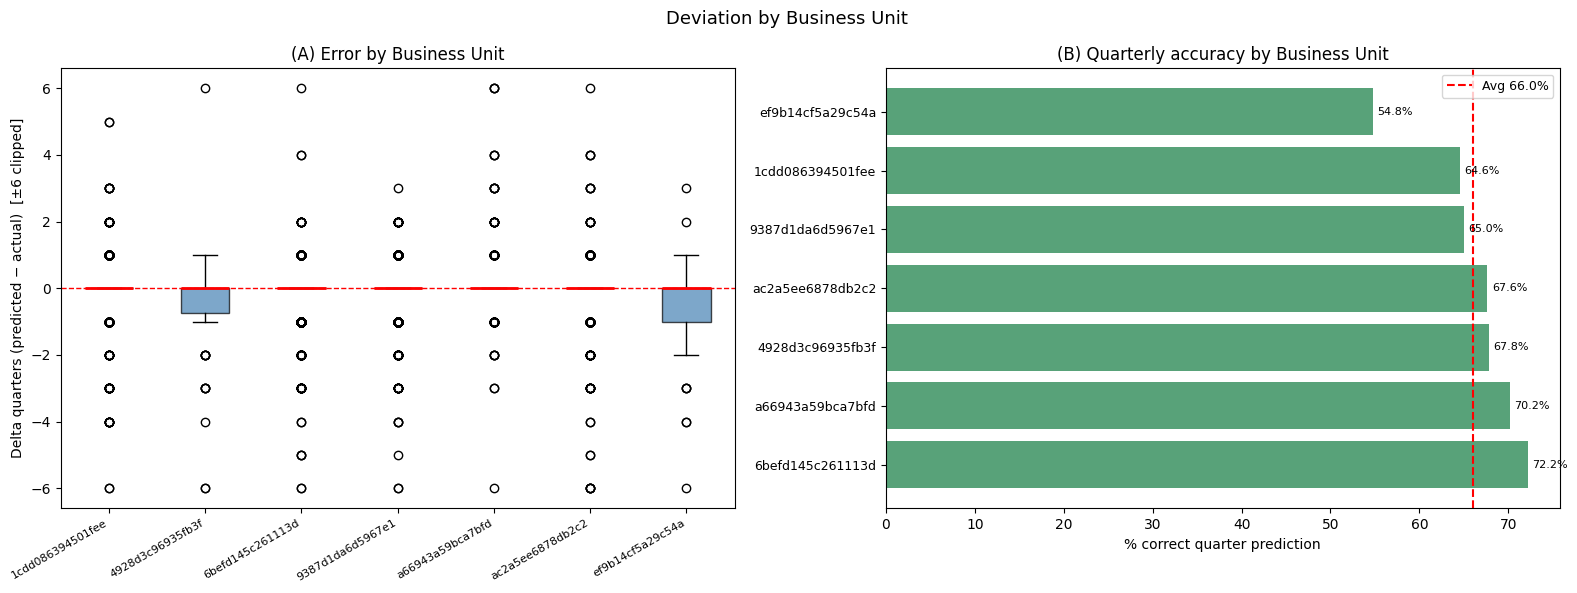

In [36]:
segment_analysis(df_pred_plot, "business_unit_label", "Business Unit")

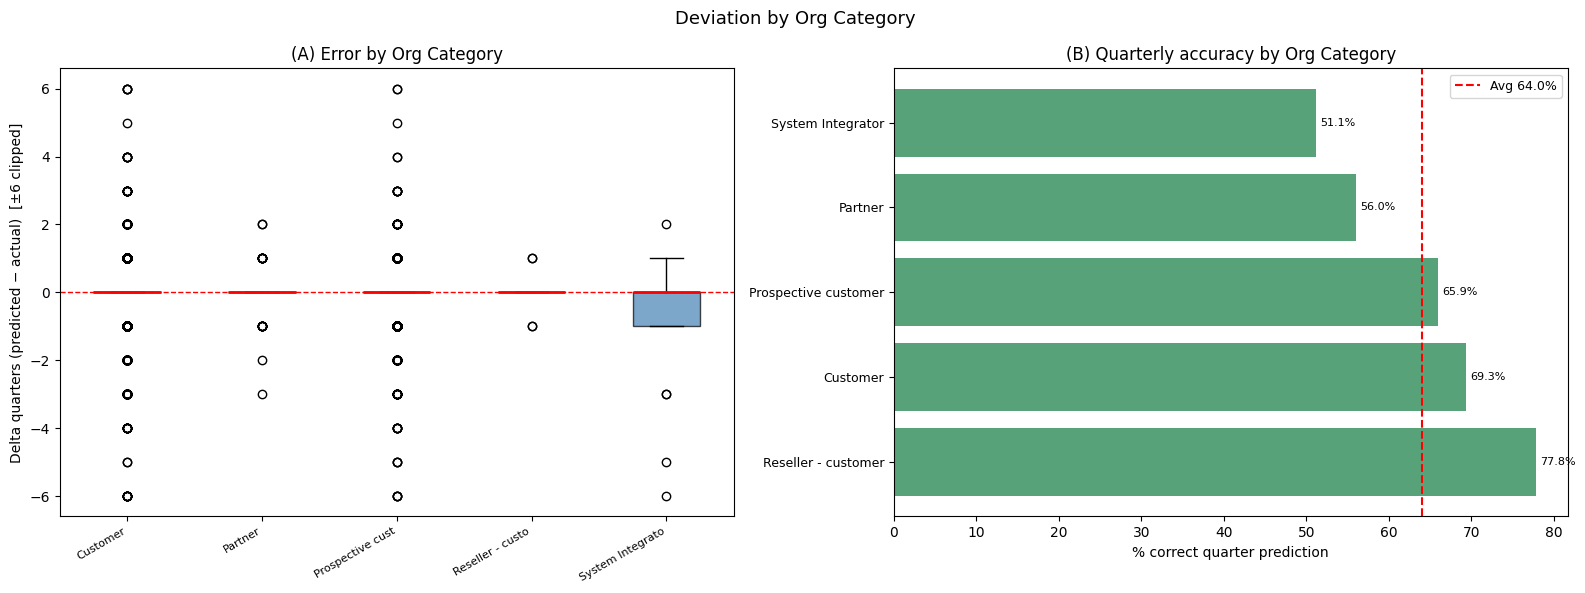

In [37]:
segment_analysis(df_pred_plot, "org_category_en_label", "Org Category")

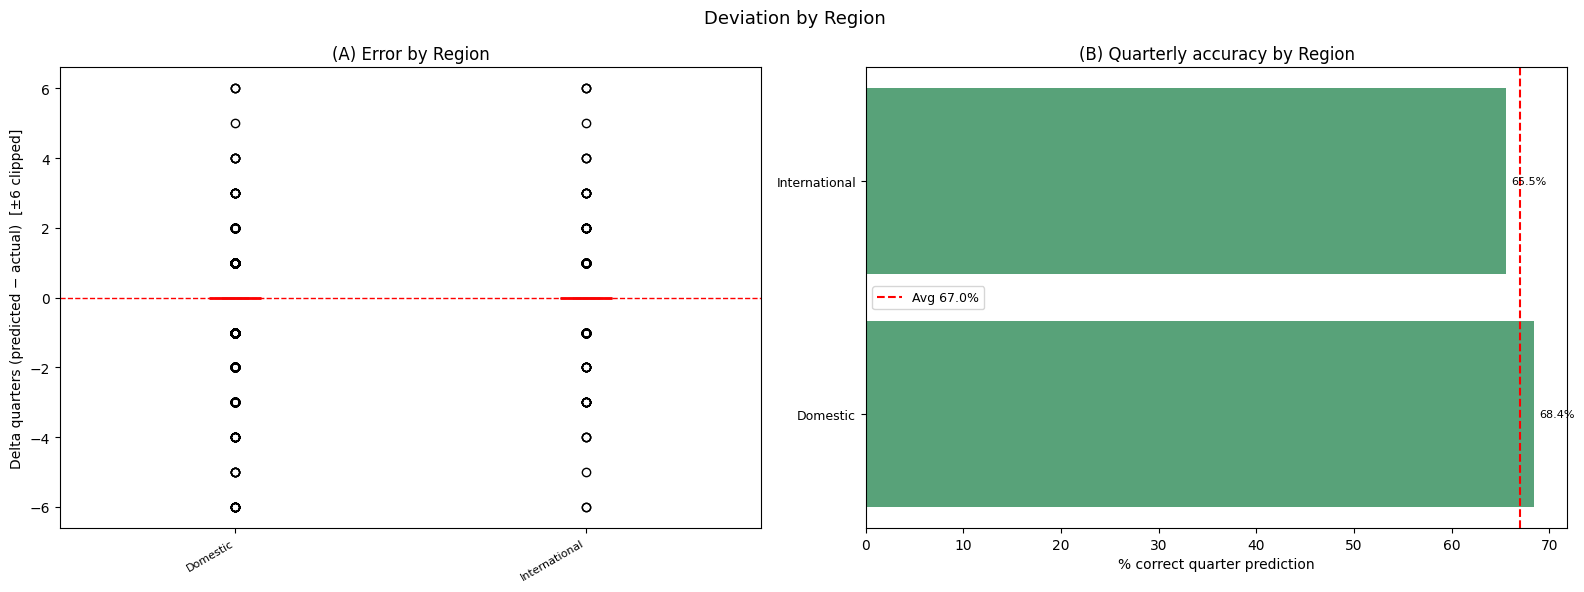

In [38]:
segment_analysis(df_pred_plot, "home_country_label", "Region")

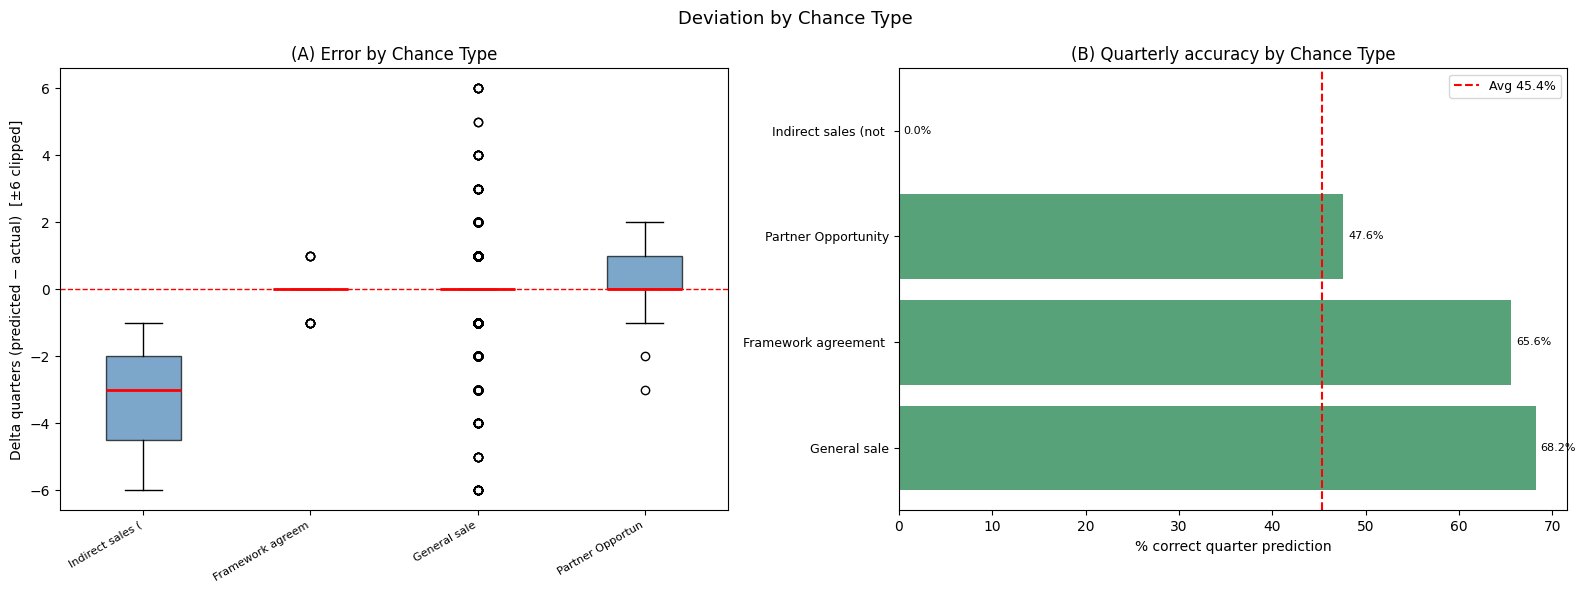

In [39]:
segment_analysis(df_pred_plot, "chance_type_en_label", "Chance Type")

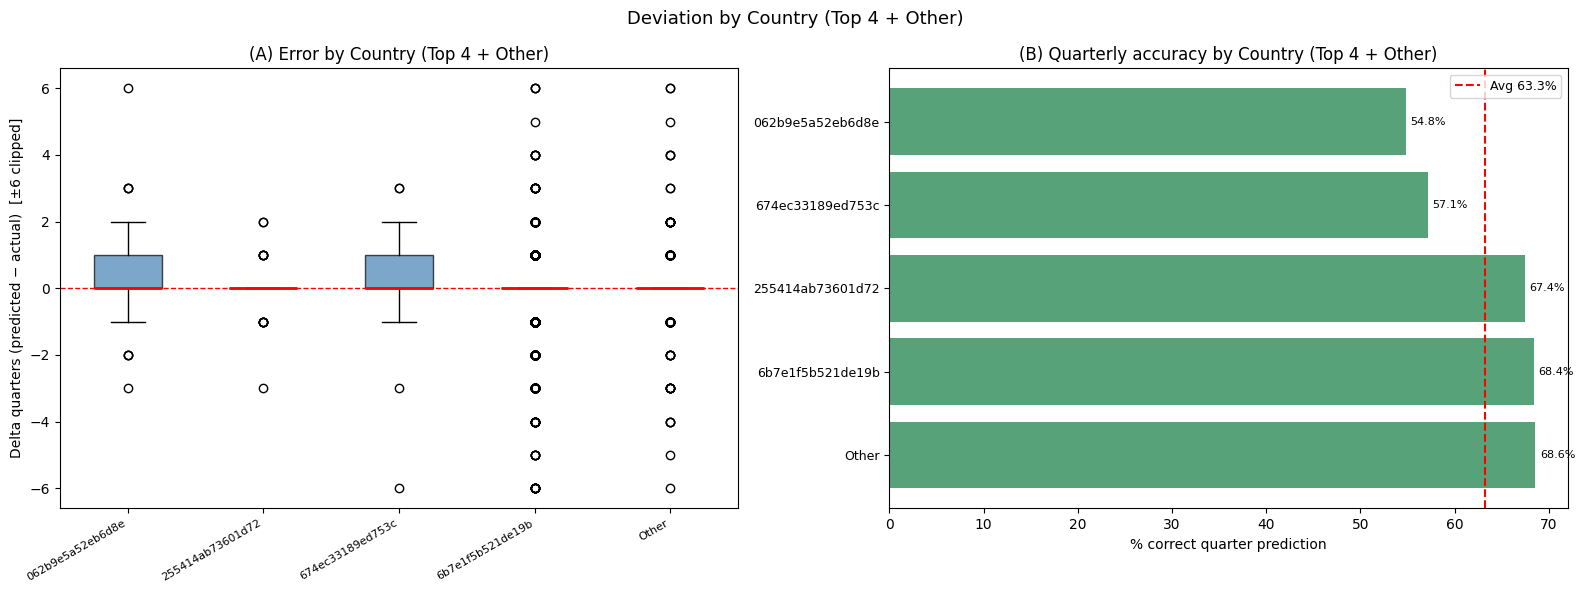

In [40]:
segment_analysis(df_pred_plot, "country_group", f"Country (Top {top_n} + Other)")

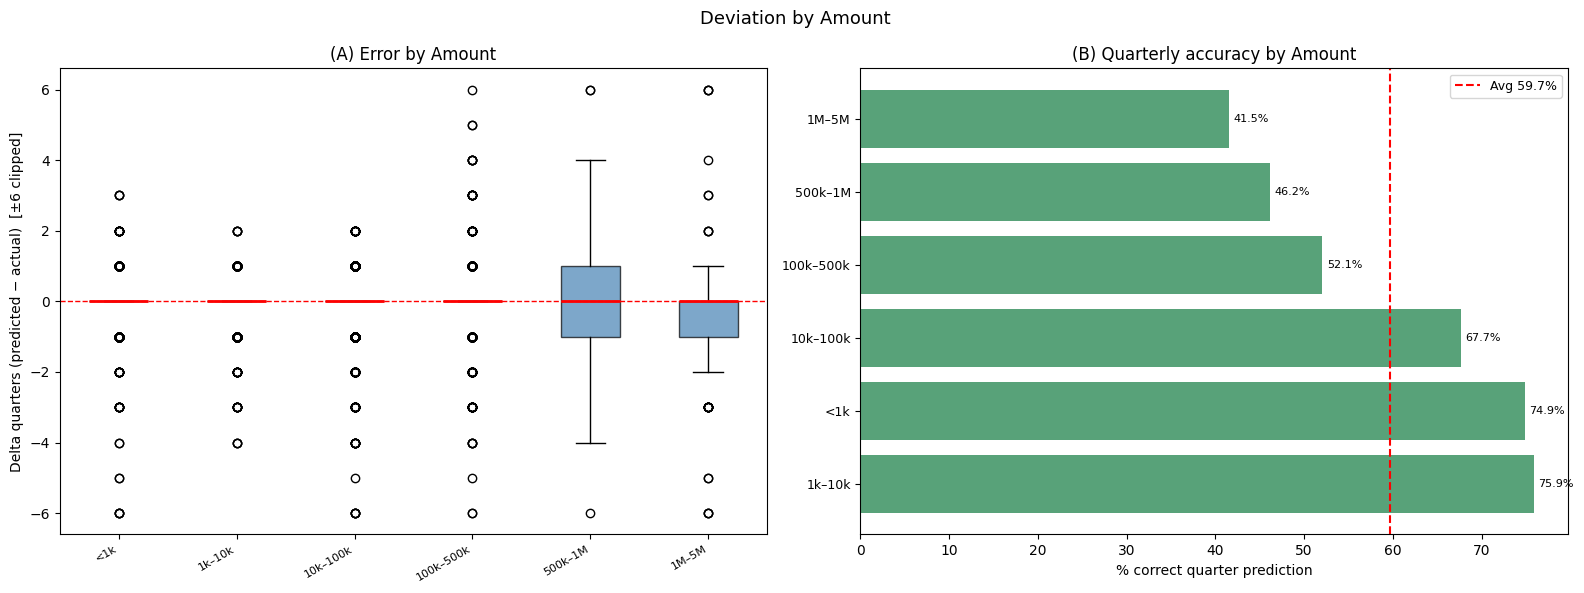

In [42]:
segment_analysis(df_pred_plot, "amount_init", "Amount",
                 bucket_cfg={"method": "cut",
                             "bins": [0, 1_000, 10_000, 100_000, 500_000, 1_000_000, 5_000_000, float("inf")],
                             "labels": ["<1k", "1k–10k", "10k–100k", "100k–500k", "500k–1M", "1M–5M", ">5M"]})

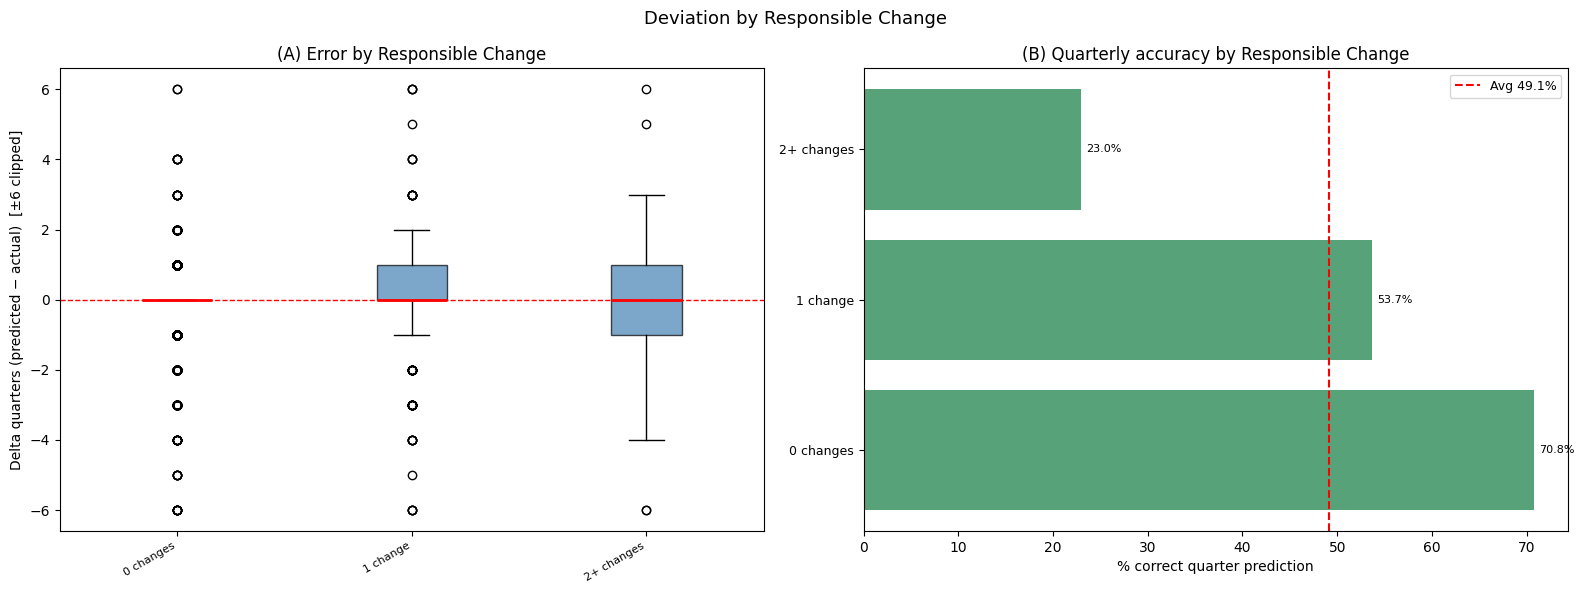

In [43]:
segment_analysis(df_pred_plot, "resp_change", "Responsible Change",
                 bucket_cfg={"method": "cut",
                             "bins": [-0.5, 0.5, 1.5, float("inf")],
                             "labels": ["0 changes", "1 change", "2+ changes"]})

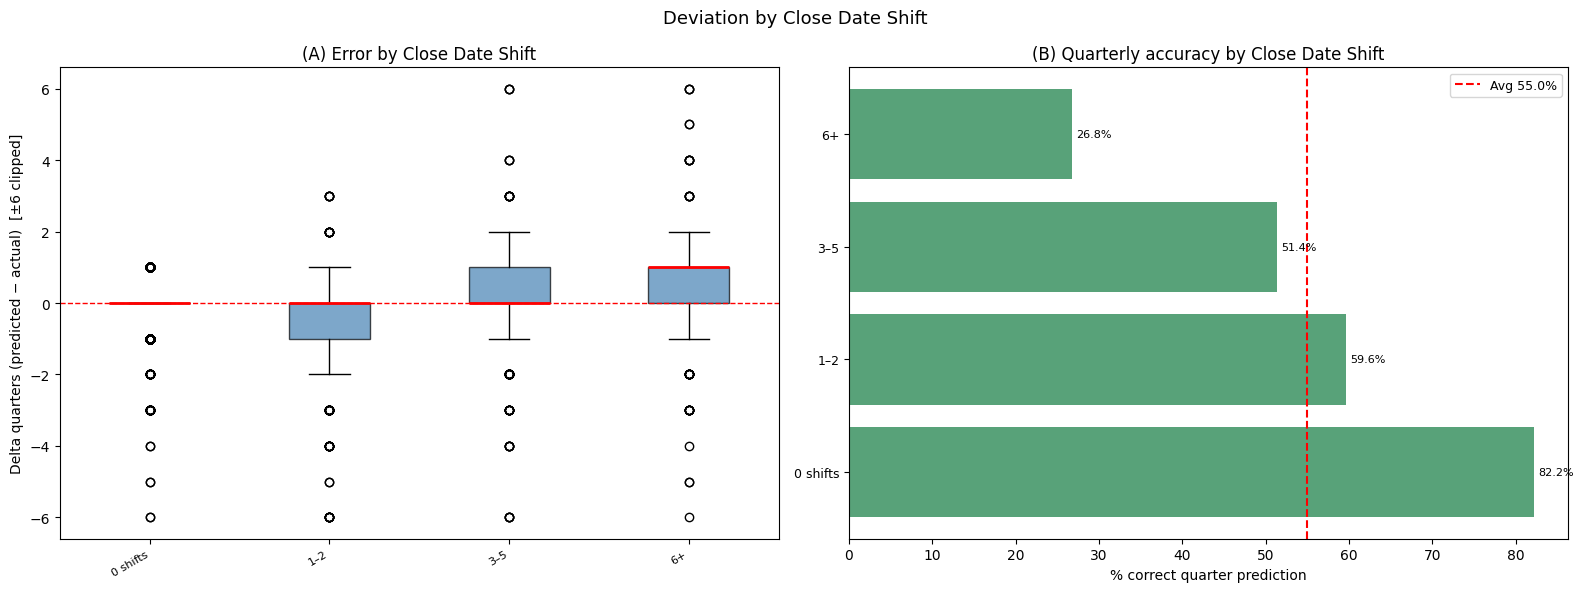

In [44]:
segment_analysis(df_pred_plot, "close_date_shift", "Close Date Shift",
                 bucket_cfg={"method": "cut",
                             "bins": [-0.5, 0.5, 2.5, 5.5, float("inf")],
                             "labels": ["0 shifts", "1–2", "3–5", "6+"]})

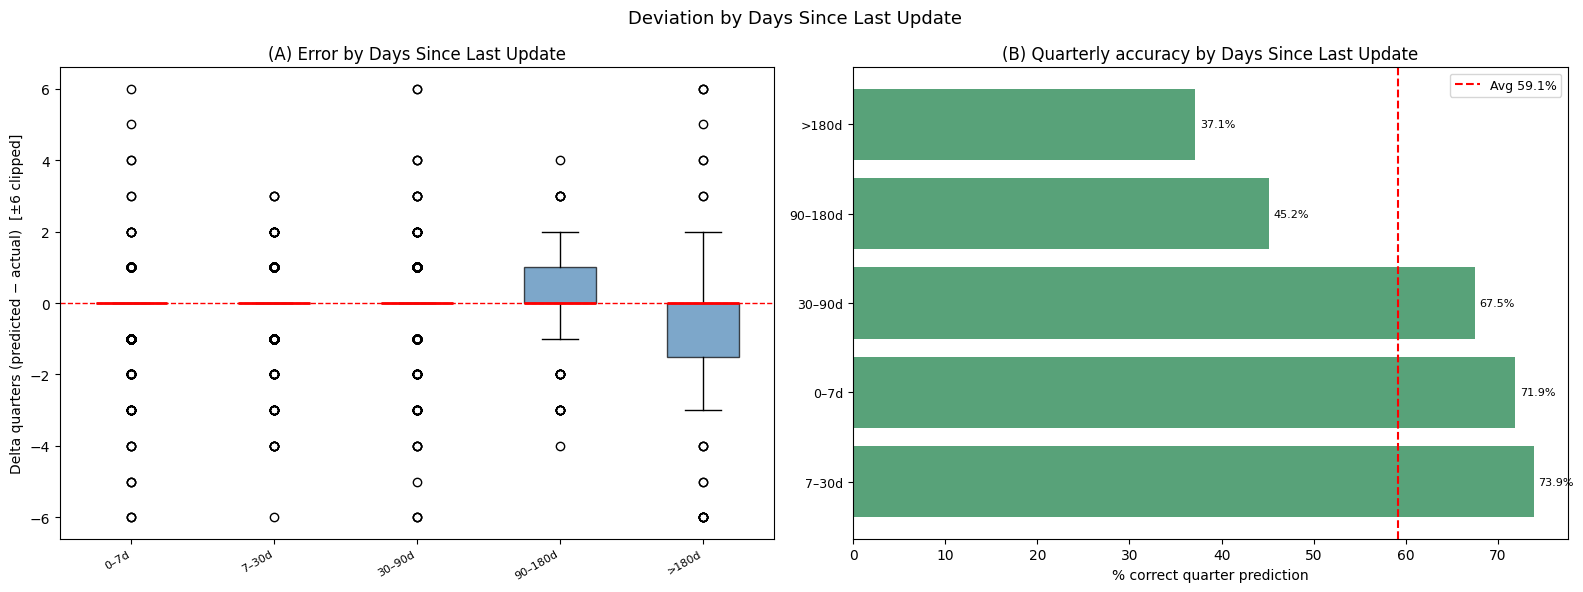

In [45]:
segment_analysis(df_pred_plot, "days_since_last_update", "Days Since Last Update",
                 bucket_cfg={"method": "cut",
                             "bins": [0, 7, 30, 90, 180, float("inf")],
                             "labels": ["0–7d", "7–30d", "30–90d", "90–180d", ">180d"]})

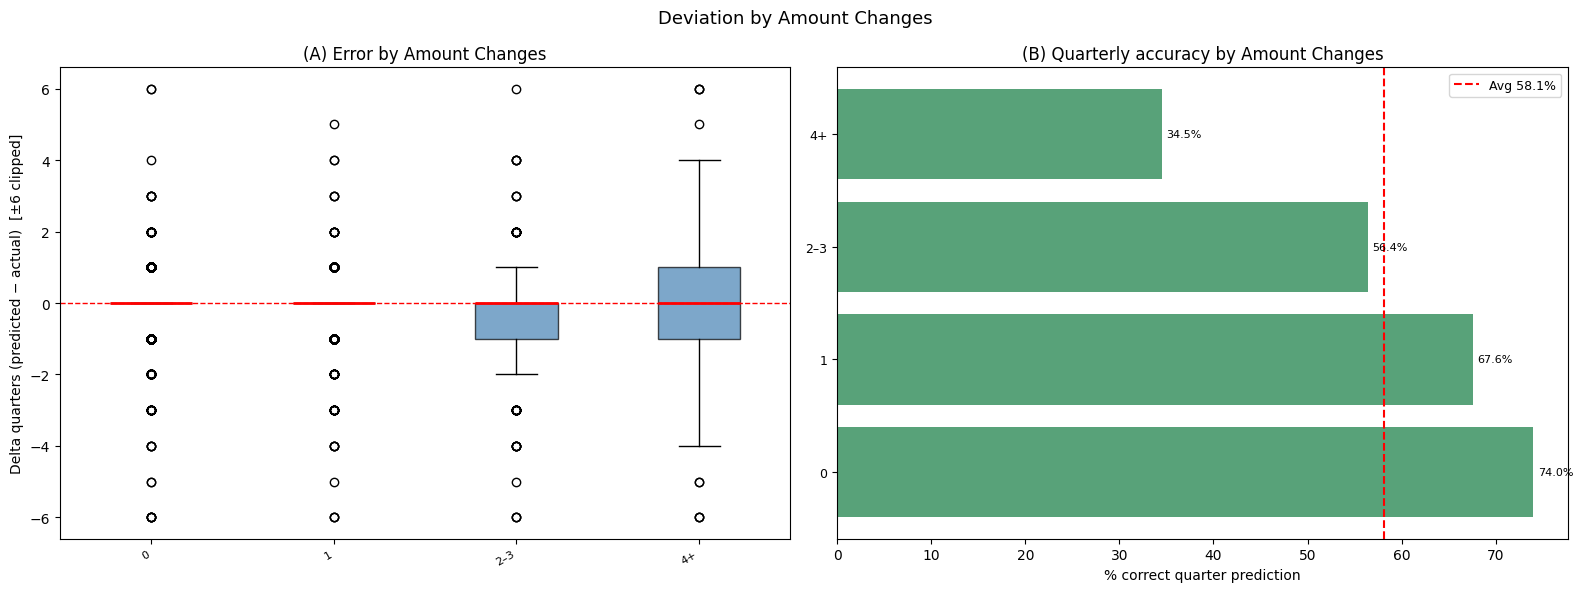

In [47]:
segment_analysis(df_pred_plot, "amount_changes", "Amount Changes",
                 bucket_cfg={"method": "cut",
                             "bins": [-0.5, 0.5, 1.5, 3.5, float('inf')],
                           'labels': ['0', '1', '2–3', '4+']})

### Segment Analysis — Key Findings

**Business Unit** — Tight range (54.8%–72.2%). The previously slow-closing BU outlier (`4928d3c96935fb3f`, 67.8%) performs close to average. Current-state
features have largely equalised performance across BUs compared to the creation-time model.

**Org Category** — Reseller-customer (77.8%) and Customer (69.3%) are most predictable. Partner (56.0%) and System Integrator (51.1%) are below average, consistent with their complex, longer-running deal dynamics confirmed in CPH.

**Region** — Effectively no difference: Domestic 68.4% vs International 66.5%. Confirms the CPH finding that `home_country` loses significance once current-state features are controlled for.

**Chance Type** — General sale (68.2%) and Framework agreement (65.6%) are well predicted. Partner Opportunity (47.6%) is significantly below average, consistent with CPH HR=0.34. Indirect sales (0.0%) is too sparse to be meaningful.

**Country** — Moderate spread (54.8%–68.6%). The dominant country performs at 68.4%, slightly above average. Two minority countries are below average, likely reflecting smaller samples and different deal dynamics.

**Amount** — Clear inverse relationship: smaller deals are more predictable (1k–10k: 75.9%, <1k: 74.9%) while larger deals are harder (500k–1M: 46.2%, 1M–5M: 41.5%). The model is most reliable for deals below €100k. Deals above €500k should be treated as high-uncertainty predictions.

**Responsible Change** — Strong monotonic degradation: 0 changes (70.8%) --> 1 change (53.7%) --> 2+ changes (23.0%). Deals with multiple rep changes are effectively unpredictable at the quarter level and should be flagged as high-uncertainty in production.

**Close Date Shift** — Most revealing CRM hygiene segment. 0 shifts (82.2%) is the best-predicted group by a large margin, performance degrades monotonically to 6+ shifts (26.8%). Confirms that `saledate_ever_updated` is capturing the dominant signal in the model — deals where reps actively maintain the saledate field are far more predictable than those where they do not.

**Days Since Last Update** — Recently updated deals are most predictable (0–7d: 71.9%, 7–30d: 73.9%). Performance degrades sharply for stale deals: 90–180d (45.2%), >180d (37.1%). Deals not updated for over 3 months are essentially unpredictable — prediction reliability should be communicated alongside a staleness indicator in production.

**Amount Changes** — Monotonic degradation: 0 changes (74.0%) --> 1 (67.6%) --> 2–3 (50.4%) --> 4+ (34.5%). Heavily revised deals are the hardest to predict, consistent across KM, CPH, and TtE. The 4+ bucket is at the margin of actionable prediction quality.

---

**Operational recommendations:**

- Flag deals with 2+ rep changes, 6+ date shifts, or >90 days since last update as **high-uncertainty predictions** in any downstream reporting
- Communicate prediction accuracy by deal size — headline 68% exact quarter applies to the full portfolio but drops to ~41% for deals above €1M
- Prioritise CRM hygiene improvement for reps who never update the saledate field. This single behaviour is the largest driver of prediction accuracy variation across the portfolio

In [48]:
# Save model artifacts for downstream use
import joblib
import json as _j
import os

_save_dir = "../data/model_artifacts"
os.makedirs(_save_dir, exist_ok=True)

# XGBoost AFT model
xgb_aft.save_model(f"{_save_dir}/xgb_aft.json")

# OrdinalEncoder — needed to encode categoricals for new predictions
joblib.dump(enc, f"{_save_dir}/ordinal_encoder_aft.joblib")

# Feature list — needed to ensure correct column order at prediction time
with open(f"{_save_dir}/aft_features.json", "w") as _f:
    _j.dump(FEATURES, _f)

# Feature group classification — needed for production feature pipeline
feature_groups = {
    "creation":      CREATION_FEATURES,
    "current_state": CURRENT_STATE_FEATURES,
    "crm_flagged":   CRM_FLAGGED_FEATURES,
}
with open(f"{_save_dir}/aft_feature_groups.json", "w") as _f:
    _j.dump(feature_groups, _f)

# Categorical columns used by encoder — needed for correct encoding at inference
with open(f"{_save_dir}/cat_cols.json", "w") as _f:
    _j.dump(cat_cols, _f)

print(f"Saved to {_save_dir}/")
print(f"  xgb_aft.json              — XGBoost AFT model")
print(f"  ordinal_encoder_aft.joblib — OrdinalEncoder for categoricals")
print(f"  aft_features.json          — {len(FEATURES)} features in correct order")
print(f"  aft_feature_groups.json    — creation / current_state / crm_flagged split")
print(f"  cat_cols.json              — categorical columns for encoder")

Saved to ../data/model_artifacts/
  xgb_aft.json              — XGBoost AFT model
  ordinal_encoder_aft.joblib — OrdinalEncoder for categoricals
  aft_features.json          — 23 features in correct order
  aft_feature_groups.json    — creation / current_state / crm_flagged split
  cat_cols.json              — categorical columns for encoder
